# TFM 2.- CALIFICACIONES CREDITICIAS SOBERANAS Y TERRITORIALES

     m o-o l o-a l o
     molopezalonso@gmail.com
     Mónica López Alonso

En este segundo notebook se recopilan y procesan las calificaciones crediticias asignadas por Moody's Investors Service, Standard & Poor's y Fitch Ratings a Estados soberanos y territorios con una calificación pública comparable.

El objetivo es construir la variable objetivo del modelo de predicción del riesgo país. Para ello, se utilizarán las variables explicativas del año \(t\) para predecir la calificación crediticia correspondiente al año \(t+1\).

El proceso desarrollado en este notebook comprende:

1. Recuperación del panel macroeconómico de referencia.
2. Descarga de las calificaciones disponibles en CountryEconomy.
3. Descarga complementaria de calificaciones para países y territorios no cubiertos por la fuente inicial.
4. Homogeneización de nombres, códigos ISO3, agencias y tipos de emisor.
5. Separación de la calificación, la perspectiva y el estado del rating.
6. Construcción del histórico de eventos de calificación.
7. Creación del panel anual de calificaciones vigentes entre 2000 y 2025.
8. Transformación de las escalas de Moody's, S&P y Fitch a una escala ordinal común.
9. Construcción de la variable objetivo adelantada un año.
10. Análisis de cobertura y guardado de los datos.

> `Variables explicativas: 2000–2024`
> 
> `Ratings necesarios:     2000–2025`
>
> `Objetivo:      rating del año t+1`

## Calificaciones crediticias soberanas y territoriales

La variable objetivo está formada por las calificaciones crediticias asignadas por Moody's Investors Service, Standard & Poor's y Fitch Ratings a Estados soberanos y territorios con una calificación pública comparable.

Se utilizarán preferentemente las calificaciones de emisor o de gobierno a largo plazo en escala internacional y denominadas en moneda extranjera. No se incluirán calificaciones de empresas, bancos, escalas nacionales ni emisiones concretas de deuda cuando no representen la calidad crediticia general del gobierno.

Los datos se recopilan inicialmente en forma de eventos de calificación. Cada observación contiene la entidad, el tipo de emisor, la agencia, la fecha de la acción, la calificación, la perspectiva y el estado del rating.

Posteriormente, los eventos se transforman en un panel anual tomando la última calificación vigente a 31 de diciembre de cada año. Cuando no se produce una modificación, se mantiene la calificación del año anterior hasta que la agencia publique una nueva acción o retire el rating.

Las escalas originales de Moody's, S&P y Fitch se conservarán y posteriormente se transformarán a una escala ordinal común, en la que los valores más elevados representarán una mayor calidad crediticia.

Las variables explicativas abarcan el periodo 2000-2024, mientras que las calificaciones crediticias se recopilan hasta 2025. De esta forma, las variables del año \(t\) podrán utilizarse para predecir la calificación del año \(t+1\).

In [1]:
from pathlib import Path
from io import StringIO
from urllib.parse import urljoin, urlparse
import re
import time

import numpy as np
import pandas as pd
import requests
import country_converter as coco

from bs4 import BeautifulSoup
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from IPython.display import display

In [2]:
START_YEAR = 2000
MACRO_END_YEAR = 2024
RATING_END_YEAR = MACRO_END_YEAR + 1


# Carpetas del proyecto

RAW_PATH = Path("data/raw")

PROCESSED_PATH = Path("data/processed")

RATINGS_RAW_PATH = (
    RAW_PATH
    / "government_credit_ratings"
)


RAW_PATH.mkdir(
    parents=True,
    exist_ok=True
)

PROCESSED_PATH.mkdir(
    parents=True,
    exist_ok=True
)

RATINGS_RAW_PATH.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
# se comprueba que estamos en la carpera correcta
print(
    "Carpeta de trabajo:",
    Path.cwd()
)

print(
    "Carpeta de datos originales:",
    RAW_PATH
)

print(
    "Carpeta de datos procesados:",
    PROCESSED_PATH
)

print(
    "Carpeta de calificaciones crediticias:",
    RATINGS_RAW_PATH
)

print(
    "Periodo de las variables explicativas:",
    f"{START_YEAR}-{MACRO_END_YEAR}"
)

print(
    "Periodo de las calificaciones:",
    f"{START_YEAR}-{RATING_END_YEAR}"
)

Carpeta de trabajo: C:\Users\pedro.lopez\Desktop\MASTER\TFM
Carpeta de datos originales: data\raw
Carpeta de datos procesados: data\processed
Carpeta de calificaciones crediticias: data\raw\government_credit_ratings
Periodo de las variables explicativas: 2000-2024
Periodo de las calificaciones: 2000-2025


In [4]:
#se recupera el pimer panel (el macroeconomico), para cerciorarnos de que se utilizan 
#los mimso paises y mismos códigos
MACRO_FILE = (
    PROCESSED_PATH
    / f"wdi_macro_panel_{START_YEAR}_{MACRO_END_YEAR}.csv"
)


if not MACRO_FILE.exists():

    raise FileNotFoundError(
        "No se encuentra el panel macroeconómico:\n"
        f"{MACRO_FILE}\n\n"
        "Comprueba que el nuevo notebook está guardado "
        "en la misma carpeta que el notebook anterior."
    )


reference_panel = pd.read_csv(
    MACRO_FILE,
    usecols=[
        "iso3",
        "iso2",
        "country",
        "region",
        "income_level",
        "year"
    ],
    low_memory=False
)


print(
    "Panel de referencia cargado:",
    MACRO_FILE
)

print(
    "Dimensiones:",
    reference_panel.shape
)

display(
    reference_panel.head()
)

Panel de referencia cargado: data\processed\wdi_macro_panel_2000_2024.csv
Dimensiones: (5425, 6)


,iso3,iso2,country,region,income_level,year
0,ABW,AW,Aruba,Latin America & Caribbean,High income,2000
1,ABW,AW,Aruba,Latin America & Caribbean,High income,2001
2,ABW,AW,Aruba,Latin America & Caribbean,High income,2002
3,ABW,AW,Aruba,Latin America & Caribbean,High income,2003
4,ABW,AW,Aruba,Latin America & Caribbean,High income,2004


In [5]:
macro_entity_year_grid = (
    reference_panel
    .drop_duplicates(
        subset=[
            "iso3",
            "year"
        ]
    )
    .sort_values(
        [
            "iso3",
            "year"
        ]
    )
    .reset_index(drop=True)
)


reference_entities = (
    reference_panel[
        [
            "iso3",
            "iso2",
            "country",
            "region",
            "income_level"
        ]
    ]
    .drop_duplicates(
        subset=["iso3"]
    )
    .sort_values("iso3")
    .reset_index(drop=True)
)

In [6]:
print(
    "Número de países y territorios:",
    reference_entities["iso3"].nunique()
)

print(
    "Periodo macroeconómico:",
    macro_entity_year_grid["year"].min(),
    "-",
    macro_entity_year_grid["year"].max()
)

print(
    "Duplicados entidad-año:",
    macro_entity_year_grid.duplicated(
        [
            "iso3",
            "year"
        ]
    ).sum()
)

Número de países y territorios: 217
Periodo macroeconómico: 2000 - 2024
Duplicados entidad-año: 0


In [7]:
# ============================================================
# CONFIGURACIÓN DE LA FUENTE COUNTRYECONOMY
# ============================================================

COUNTRYECONOMY_HOME_URL = (
    "https://countryeconomy.com/ratings"
)

COUNTRYECONOMY_CHECKPOINT_FILE = (
    RATINGS_RAW_PATH
    / "countryeconomy_rating_events_checkpoint.csv"
)

COUNTRYECONOMY_ERRORS_FILE = (
    RATINGS_RAW_PATH
    / "countryeconomy_download_errors.csv"
)


def create_download_session():
    """
    Crea una sesión de descarga con reintentos
    automáticos ante errores temporales.
    """

    session = requests.Session()

    retry_strategy = Retry(
        total=4,
        connect=4,
        read=4,
        backoff_factor=1,
        status_forcelist=[
            429,
            500,
            502,
            503,
            504
        ],
        allowed_methods=["GET"]
    )

    adapter = HTTPAdapter(
        max_retries=retry_strategy
    )

    session.mount(
        "https://",
        adapter
    )

    session.mount(
        "http://",
        adapter
    )

    session.headers.update({
        "User-Agent": (
            "Mozilla/5.0 "
            "(academic research; "
            "government credit ratings TFM)"
        ),
        "Accept-Language": (
            "en-US,en;q=0.9"
        )
    })

    return session


countryeconomy_session = (
    create_download_session()
)

In [8]:
def get_countryeconomy_rating_pages(session):
    """
    Localiza automáticamente las páginas de Estados
    y territorios incluidas en CountryEconomy.
    """

    response = session.get(
        COUNTRYECONOMY_HOME_URL,
        timeout=40
    )

    response.raise_for_status()

    soup = BeautifulSoup(
        response.text,
        "html.parser"
    )

    excluded_slugs = {
        "moodys",
        "standardandpoors",
        "standard-poors",
        "sp",
        "fitch",
        "spain-autonomous-communities"
    }

    entity_pages = []

    for link in soup.find_all(
        "a",
        href=True
    ):

        full_url = urljoin(
            COUNTRYECONOMY_HOME_URL,
            link["href"]
        )

        full_url = full_url.split("?")[0]

        path = (
            urlparse(full_url)
            .path
            .rstrip("/")
        )

        match = re.fullmatch(
            r"/ratings/([^/]+)",
            path
        )

        if match is None:
            continue

        entity_slug = (
            match.group(1)
            .lower()
        )

        if entity_slug in excluded_slugs:
            continue

        entity_name = (
            link.get_text(
                " ",
                strip=True
            )
        )

        entity_name = re.sub(
            r"\[\+\]",
            "",
            entity_name
        ).strip()

        if not entity_name:
            continue

        entity_pages.append({
            "entity_source": entity_name,
            "entity_slug": entity_slug,
            "entity_url": full_url
        })

    entity_pages = (
        pd.DataFrame(entity_pages)
        .drop_duplicates(
            subset=["entity_url"]
        )
        .sort_values(
            "entity_source"
        )
        .reset_index(drop=True)
    )

    if entity_pages.empty:

        raise RuntimeError(
            "No se han localizado páginas de "
            "calificaciones en CountryEconomy."
        )

    return entity_pages

In [9]:
rating_entity_pages = (
    get_countryeconomy_rating_pages(
        countryeconomy_session
    )
)


print(
    "Páginas de entidades encontradas:",
    len(rating_entity_pages)
)


display(
    rating_entity_pages.head(15)
)

Páginas de entidades encontradas: 144


,entity_source,entity_slug,entity_url
0,Albania,albania,https://countryeconomy.com/ratings/albania
1,Andorra,andorra,https://countryeconomy.com/ratings/andorra
2,Angola,angola,https://countryeconomy.com/ratings/angola
3,Argentina,argentina,https://countryeconomy.com/ratings/argentina
4,Armenia,armenia,https://countryeconomy.com/ratings/armenia
5,Australia,australia,https://countryeconomy.com/ratings/australia
6,Austria,austria,https://countryeconomy.com/ratings/austria
7,Azerbaijan,azerbaijan,https://countryeconomy.com/ratings/azerbaijan
8,Bahamas,bahamas,https://countryeconomy.com/ratings/bahamas
9,Bahrain,bahrain,https://countryeconomy.com/ratings/bahrain


In [10]:
COUNTRYECONOMY_ENTITY_PAGES_FILE = (
    RATINGS_RAW_PATH
    / "countryeconomy_rating_entity_pages.csv"
)


rating_entity_pages.to_csv(
    COUNTRYECONOMY_ENTITY_PAGES_FILE,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Listado guardado en:",
    COUNTRYECONOMY_ENTITY_PAGES_FILE
)

Listado guardado en: data\raw\government_credit_ratings\countryeconomy_rating_entity_pages.csv


In [11]:
# ============================================================
# IDENTIFICACIÓN DE LAS AGENCIAS
# ============================================================

AGENCY_ORDER = [
    "Moody's",
    "S&P",
    "Fitch"
]


AGENCY_PATTERNS = {
    "Moody's": [
        "moody",
        "moody's"
    ],
    "S&P": [
        "s&p",
        "standard & poor",
        "standard and poor"
    ],
    "Fitch": [
        "fitch"
    ]
}


def detect_rating_agency(table_tag):
    """
    Intenta identificar la agencia a partir del
    encabezado HTML anterior a la tabla.
    """

    heading = table_tag.find_previous(
        [
            "h2",
            "h3",
            "h4"
        ]
    )

    if heading is None:
        return None

    heading_text = (
        heading.get_text(
            " ",
            strip=True
        )
        .lower()
    )

    for agency, patterns in (
        AGENCY_PATTERNS.items()
    ):

        if any(
            pattern in heading_text
            for pattern in patterns
        ):

            return agency

    return None

In [12]:
def is_rating_history_table(table_tag):
    """
    Comprueba si una tabla HTML corresponde a un
    histórico de calificaciones crediticias públicas
    de largo plazo en moneda extranjera.
    """

    table_text = (
        table_tag.get_text(
            " ",
            strip=True
        )
        .lower()
    )

    required_expressions = [
        "long term",
        "foreign currency",
        "date",
        "rating"
    ]

    return all(
        expression in table_text
        for expression in required_expressions
    )

In [13]:
def extract_entity_rating_tables(
    html_text,
    entity_name,
    entity_slug,
    entity_url
):
    """
    Extrae los históricos originales de Moody's,
    S&P y Fitch para un Estado o territorio.

    Se conservan las calificaciones de largo plazo
    en moneda extranjera.
    """

    soup = BeautifulSoup(
        html_text,
        "html.parser"
    )

    rating_table_tags = [
        table_tag
        for table_tag in soup.find_all("table")
        if is_rating_history_table(table_tag)
    ]

    if not rating_table_tags:
        return pd.DataFrame()

    entity_events = []

    detected_agencies = set()

    for table_position, table_tag in enumerate(
        rating_table_tags
    ):

        agency = detect_rating_agency(
            table_tag
        )

        # Si el encabezado no permite reconocerla,
        # se utiliza como respaldo el orden original.
        if (
            agency is None
            and table_position < len(AGENCY_ORDER)
        ):

            agency = AGENCY_ORDER[
                table_position
            ]

        if agency is None:
            continue

        if agency in detected_agencies:
            continue

        try:

            extracted_tables = pd.read_html(
                StringIO(str(table_tag))
            )

        except ValueError:
            continue

        if not extracted_tables:
            continue

        agency_table = extracted_tables[0]

        if agency_table.shape[1] < 2:
            continue

        agency_events = (
            agency_table.iloc[:, :2]
            .copy()
        )

        agency_events.columns = [
            "rating_date_raw",
            "rating_raw"
        ]

        agency_events[
            "entity_source"
        ] = entity_name

        agency_events[
            "entity_slug"
        ] = entity_slug

        agency_events[
            "agency"
        ] = agency

        agency_events[
            "rating_scope"
        ] = "long_term_foreign_currency"

        agency_events[
            "source_name"
        ] = "CountryEconomy"

        agency_events[
            "source_url"
        ] = entity_url

        agency_events = agency_events[
            [
                "entity_source",
                "entity_slug",
                "agency",
                "rating_date_raw",
                "rating_raw",
                "rating_scope",
                "source_name",
                "source_url"
            ]
        ]

        entity_events.append(
            agency_events
        )

        detected_agencies.add(
            agency
        )

    if not entity_events:
        return pd.DataFrame()

    return pd.concat(
        entity_events,
        ignore_index=True
    )

In [14]:
def download_entity_ratings(
    entity_name,
    entity_slug,
    entity_url,
    session
):
    """
    Descarga y extrae las tablas de calificaciones
    correspondientes a un Estado o territorio.
    """

    response = session.get(
        entity_url,
        timeout=40
    )

    response.raise_for_status()

    return extract_entity_rating_tables(
        html_text=response.text,
        entity_name=entity_name,
        entity_slug=entity_slug,
        entity_url=entity_url
    )

In [18]:
spain_ratings_test = (
    download_entity_ratings(
        entity_name="Spain",
        entity_slug="spain",
        entity_url=(
            "https://countryeconomy.com/ratings/spain"
        ),
        session=countryeconomy_session
    )
)


print(
    "Observaciones descargadas:",
    len(spain_ratings_test)
)


print(
    spain_ratings_test[
        "agency"
    ].value_counts(
        dropna=False
    )
)

Observaciones descargadas: 89
agency
Fitch      54
Moody's    20
S&P        15
Name: count, dtype: int64


In [19]:
if COUNTRYECONOMY_CHECKPOINT_FILE.exists():

    previous_checkpoint = pd.read_csv(
        COUNTRYECONOMY_CHECKPOINT_FILE,
        low_memory=False
    )

    downloaded_entity_urls = set(
        previous_checkpoint[
            "source_url"
        ]
        .dropna()
        .astype(str)
    )

    all_countryeconomy_events = [
        previous_checkpoint
    ]

    print(
        "Checkpoint recuperado."
    )

    print(
        "Entidades ya descargadas:",
        len(downloaded_entity_urls)
    )

else:

    downloaded_entity_urls = set()

    all_countryeconomy_events = []

    print(
        "No existe un checkpoint anterior."
    )

No existe un checkpoint anterior.


In [20]:
countryeconomy_download_errors = []

total_entities = len(
    rating_entity_pages
)


for position, row in (
    rating_entity_pages
    .reset_index(drop=True)
    .iterrows()
):

    entity_number = position + 1

    entity_url = row[
        "entity_url"
    ]

    if entity_url in downloaded_entity_urls:

        print(
            f"[{entity_number}/{total_entities}] "
            f"{row['entity_source']} — ya descargada"
        )

        continue

    print(
        f"[{entity_number}/{total_entities}] "
        f"{row['entity_source']}"
    )

    try:

        entity_events = (
            download_entity_ratings(
                entity_name=(
                    row["entity_source"]
                ),
                entity_slug=(
                    row["entity_slug"]
                ),
                entity_url=entity_url,
                session=countryeconomy_session
            )
        )

        if entity_events.empty:

            print(
                "  Sin históricos encontrados."
            )

        else:

            all_countryeconomy_events.append(
                entity_events
            )

            downloaded_entity_urls.add(
                entity_url
            )

            print(
                "  Observaciones:",
                len(entity_events)
            )

    except Exception as error:

        countryeconomy_download_errors.append({
            "entity_source": (
                row["entity_source"]
            ),
            "entity_slug": (
                row["entity_slug"]
            ),
            "entity_url": entity_url,
            "error": str(error)
        })

        print(
            "  Error:",
            str(error)
        )

    # Guardado provisional cada diez entidades
    if (
        all_countryeconomy_events
        and entity_number % 10 == 0
    ):

        checkpoint = pd.concat(
            all_countryeconomy_events,
            ignore_index=True
        )

        checkpoint = (
            checkpoint
            .drop_duplicates()
            .reset_index(drop=True)
        )

        checkpoint.to_csv(
            COUNTRYECONOMY_CHECKPOINT_FILE,
            index=False,
            encoding="utf-8-sig"
        )

        print(
            "  Checkpoint guardado."
        )

    # Pausa para evitar peticiones demasiado rápidas
    time.sleep(0.5)


# Guardado final del checkpoint
if all_countryeconomy_events:

    final_checkpoint = pd.concat(
        all_countryeconomy_events,
        ignore_index=True
    )

    final_checkpoint = (
        final_checkpoint
        .drop_duplicates()
        .reset_index(drop=True)
    )

    final_checkpoint.to_csv(
        COUNTRYECONOMY_CHECKPOINT_FILE,
        index=False,
        encoding="utf-8-sig"
    )

    print(
        "Checkpoint final guardado."
    )

[1/144] Albania
  Observaciones: 16
[2/144] Andorra
  Observaciones: 28
[3/144] Angola
  Observaciones: 48
[4/144] Argentina
  Observaciones: 116
[5/144] Armenia
  Observaciones: 34
[6/144] Australia
  Observaciones: 55
[7/144] Austria
  Observaciones: 61
[8/144] Azerbaijan
  Observaciones: 54
[9/144] Bahamas
  Observaciones: 24
[10/144] Bahrain
  Observaciones: 107
  Checkpoint guardado.
[11/144] Bangladesh
  Observaciones: 22
[12/144] Barbados
  Observaciones: 30
[13/144] Belarus
  Observaciones: 37
[14/144] Belgium
  Observaciones: 73
[15/144] Belize
  Observaciones: 37
[16/144] Benin
  Observaciones: 10
[17/144] Bolivia
  Observaciones: 61
[18/144] Bosnia and Herzegovina
  Observaciones: 20
[19/144] Botswana
  Observaciones: 24
[20/144] Brazil
  Observaciones: 96
  Checkpoint guardado.
[21/144] Bulgaria
  Observaciones: 74
[22/144] Burkina Faso
  Observaciones: 6
[23/144] Cabo Verde
  Observaciones: 35
[24/144] Cambodia
  Observaciones: 11
[25/144] Cameroon
  Observaciones: 31
[26/

In [21]:
if not all_countryeconomy_events:

    raise RuntimeError(
        "No se ha descargado ningún histórico "
        "de calificaciones desde CountryEconomy."
    )


countryeconomy_events_raw = pd.concat(
    all_countryeconomy_events,
    ignore_index=True
)


countryeconomy_events_raw = (
    countryeconomy_events_raw
    .drop_duplicates(
        subset=[
            "entity_slug",
            "agency",
            "rating_date_raw",
            "rating_raw",
            "source_url"
        ]
    )
    .reset_index(drop=True)
)


countryeconomy_errors = pd.DataFrame(
    countryeconomy_download_errors
)


print(
    "Observaciones descargadas:",
    len(countryeconomy_events_raw)
)

print(
    "Entidades con datos:",
    countryeconomy_events_raw[
        "entity_source"
    ].nunique()
)

print(
    "Errores registrados:",
    len(countryeconomy_errors)
)


display(
    countryeconomy_events_raw.head(20)
)

Observaciones descargadas: 7440
Entidades con datos: 144
Errores registrados: 0


,entity_source,entity_slug,agency,rating_date_raw,rating_raw,rating_scope,source_name,source_url
0,Albania,albania,Moody's,2024-10-18,Ba3 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania
1,Albania,albania,Moody's,2024-04-19,B1 (Positive),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania
2,Albania,albania,Moody's,2023-04-07,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania
3,Albania,albania,Moody's,2021-05-21,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania
4,Albania,albania,Moody's,2019-08-02,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania
5,Albania,albania,Moody's,2017-08-04,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania
6,Albania,albania,Moody's,2014-08-12,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania
7,Albania,albania,Moody's,2007-06-29,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania
8,Albania,albania,S&P,2025-03-21,BB (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania
9,Albania,albania,S&P,2024-03-22,BB- (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania


In [22]:
text_columns = [
    "entity_source",
    "entity_slug",
    "agency",
    "rating_date_raw",
    "rating_raw",
    "rating_scope",
    "source_name",
    "source_url"
]


for column in text_columns:

    if column not in countryeconomy_events_raw.columns:
        continue

    countryeconomy_events_raw[
        column
    ] = (
        countryeconomy_events_raw[
            column
        ]
        .astype("string")
        .str.strip()
        .replace({
            "": pd.NA,
            "nan": pd.NA,
            "None": pd.NA,
            "<NA>": pd.NA
        })
    )

In [23]:
invalid_date_values = {
    "Date",
    "Fecha"
}


invalid_rating_values = {
    "Rating",
    "Calificación"
}


countryeconomy_events_raw = (
    countryeconomy_events_raw[
        countryeconomy_events_raw[
            "rating_date_raw"
        ].notna()
        &
        countryeconomy_events_raw[
            "rating_raw"
        ].notna()
        &
        ~countryeconomy_events_raw[
            "rating_date_raw"
        ].isin(
            invalid_date_values
        )
        &
        ~countryeconomy_events_raw[
            "rating_raw"
        ].isin(
            invalid_rating_values
        )
    ]
    .drop_duplicates(
        subset=[
            "entity_slug",
            "agency",
            "rating_date_raw",
            "rating_raw",
            "source_url"
        ]
    )
    .reset_index(drop=True)
)

In [24]:
countryeconomy_events_raw[
    "rating_date"
] = pd.to_datetime(
    countryeconomy_events_raw[
        "rating_date_raw"
    ],
    errors="coerce"
)

In [25]:
print(
    "Primera fecha válida:",
    countryeconomy_events_raw[
        "rating_date"
    ].min()
)

print(
    "Última fecha válida:",
    countryeconomy_events_raw[
        "rating_date"
    ].max()
)

print(
    "Fechas no reconocidas:",
    countryeconomy_events_raw[
        "rating_date"
    ].isna().sum()
)

print(
    "Eventos posteriores a 2025:",
    (
        countryeconomy_events_raw[
            "rating_date"
        ]
        >
        pd.Timestamp(
            f"{RATING_END_YEAR}-12-31"
        )
    ).sum()
)

Primera fecha válida: 1949-02-05 00:00:00
Última fecha válida: 2026-06-19 00:00:00
Fechas no reconocidas: 64
Eventos posteriores a 2025: 52


In [26]:
countryeconomy_unrecognized_dates = (
    countryeconomy_events_raw[
        countryeconomy_events_raw[
            "rating_date"
        ].isna()
    ][
        [
            "entity_source",
            "entity_slug",
            "agency",
            "rating_date_raw",
            "rating_raw",
            "source_url"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "entity_source",
            "agency",
            "rating_date_raw"
        ]
    )
    .reset_index(drop=True)
)


print(
    "Número de registros con fecha no reconocida:",
    len(countryeconomy_unrecognized_dates)
)


display(
    countryeconomy_unrecognized_dates.head(50)
)


COUNTRYECONOMY_UNRECOGNIZED_DATES_FILE = (
    RATINGS_RAW_PATH
    / "countryeconomy_unrecognized_dates.csv"
)


countryeconomy_unrecognized_dates.to_csv(
    COUNTRYECONOMY_UNRECOGNIZED_DATES_FILE,
    index=False,
    encoding="utf-8-sig"
)

Número de registros con fecha no reconocida: 64


,entity_source,entity_slug,agency,rating_date_raw,rating_raw,source_url
0,Argentina,argentina,Fitch,0000-00-00,B- (Stable),https://countryeconomy.com/ratings/argentina
1,Armenia,armenia,Fitch,0000-00-00,BB- (Stable),https://countryeconomy.com/ratings/armenia
2,Austria,austria,Fitch,0000-00-00,AA (Stable),https://countryeconomy.com/ratings/austria
3,Azerbaijan,azerbaijan,Fitch,0000-00-00,BBB- (Stable),https://countryeconomy.com/ratings/azerbaijan
4,Bahrain,bahrain,Fitch,0000-00-00,B (Stable),https://countryeconomy.com/ratings/bahrain
5,Bangladesh,bangladesh,Fitch,0000-00-00,B+ (Stable),https://countryeconomy.com/ratings/bangladesh
6,Barbados,barbados,Fitch,0000-00-00,B+ (Stable),https://countryeconomy.com/ratings/barbados
7,Belgium,belgium,Fitch,0000-00-00,A+ (Stable),https://countryeconomy.com/ratings/belgium
8,Bolivia,bolivia,Fitch,0000-00-00,CCC,https://countryeconomy.com/ratings/bolivia
9,Brazil,brazil,Fitch,0000-00-00,BB (Stable),https://countryeconomy.com/ratings/brazil


In [28]:
rating_period_start_date = pd.Timestamp(
    f"{START_YEAR}-01-01"
)

rating_period_end_date = pd.Timestamp(
    f"{RATING_END_YEAR}-12-31"
)


countryeconomy_events_2000_2025  = (
    countryeconomy_events_raw[
        countryeconomy_events_raw[
            "rating_date"
        ].between(
            rating_period_start_date,
            rating_period_end_date
        )
    ]
    .sort_values(
        [
            "entity_source",
            "agency",
            "rating_date"
        ]
    )
    .reset_index(drop=True)
)

In [29]:
print(
    f"Eventos entre {START_YEAR} y "
    f"{RATING_END_YEAR}:",
    len(countryeconomy_events_2000_2025)
)

print(
    "Entidades:",
    countryeconomy_events_2000_2025[
        "entity_source"
    ].nunique()
)

print(
    "Agencias:",
    countryeconomy_events_2000_2025[
        "agency"
    ].nunique()
)


display(
    countryeconomy_events_2000_2025.head(20)
)

Eventos entre 2000 y 2025: 6806
Entidades: 144
Agencias: 3


,entity_source,entity_slug,agency,rating_date_raw,rating_raw,rating_scope,source_name,source_url,rating_date
0,Albania,albania,Moody's,2007-06-29,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania,2007-06-29
1,Albania,albania,Moody's,2014-08-12,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania,2014-08-12
2,Albania,albania,Moody's,2017-08-04,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania,2017-08-04
3,Albania,albania,Moody's,2019-08-02,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania,2019-08-02
4,Albania,albania,Moody's,2021-05-21,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania,2021-05-21
5,Albania,albania,Moody's,2023-04-07,B1 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania,2023-04-07
6,Albania,albania,Moody's,2024-04-19,B1 (Positive),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania,2024-04-19
7,Albania,albania,Moody's,2024-10-18,Ba3 (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania,2024-10-18
8,Albania,albania,S&P,2010-04-19,B+ (Stable),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania,2010-04-19
9,Albania,albania,S&P,2013-12-06,B (Negative),long_term_foreign_currency,CountryEconomy,https://countryeconomy.com/ratings/albania,2013-12-06


In [30]:
countryeconomy_download_summary = (
    countryeconomy_events_2000_2025
    .groupby(
        "agency",
        as_index=False
    )
    .agg(
        observations=(
            "rating_raw",
            "count"
        ),
        entities=(
            "entity_source",
            "nunique"
        ),
        first_date=(
            "rating_date",
            "min"
        ),
        last_date=(
            "rating_date",
            "max"
        )
    )
    .sort_values("agency")
    .reset_index(drop=True)
)


display(
    countryeconomy_download_summary
)

,agency,observations,entities,first_date,last_date
0,Fitch,4049,125,2000-02-03,2023-05-05
1,Moody's,1668,110,2000-01-05,2025-12-19
2,S&P,1089,123,2000-05-02,2025-12-18


In [31]:
display(
    countryeconomy_events_2000_2025[
        countryeconomy_events_2000_2025[
            "entity_slug"
        ].eq("spain")
    ][
        [
            "entity_source",
            "agency",
            "rating_date",
            "rating_raw"
        ]
    ]
    .sort_values(
        [
            "agency",
            "rating_date"
        ]
    )
    .reset_index(drop=True)
)

,entity_source,agency,rating_date,rating_raw
0,Spain,Fitch,2000-09-21,AA+ (Stable)
1,Spain,Fitch,2003-12-10,AAA (Stable)
2,Spain,Fitch,2010-05-28,AA+ (Stable)
3,Spain,Fitch,2011-03-04,AA+ (Negative)
4,Spain,Fitch,2011-10-07,AA- (Negative)
...,...,...,...,...
76,Spain,S&P,2018-03-23,A- (Positive)
77,Spain,S&P,2019-09-20,A (Stable)
78,Spain,S&P,2020-09-18,(Negative)
79,Spain,S&P,2022-03-18,A (Stable)


In [32]:
# Histórico completo descargado
COUNTRYECONOMY_FULL_FILE = (
    RATINGS_RAW_PATH
    / "countryeconomy_rating_events_raw_full.csv"
)

COUNTRYECONOMY_PERIOD_FILE = (
    RATINGS_RAW_PATH
    / (
        "countryeconomy_rating_events_"
        f"{START_YEAR}_{RATING_END_YEAR}.csv"
    )
)

COUNTRYECONOMY_SUMMARY_FILE = (
    RATINGS_RAW_PATH
    / "countryeconomy_download_summary.csv"
)


# Histórico completo, necesario para arrastrar ratings anteriores a 2000

countryeconomy_events_raw.to_csv(
    COUNTRYECONOMY_FULL_FILE,
    index=False,
    encoding="utf-8-sig"
)


# Eventos producidos durante 2000-2025

countryeconomy_events_2000_2025.to_csv(
    COUNTRYECONOMY_PERIOD_FILE,
    index=False,
    encoding="utf-8-sig"
)


# Resumen por agencia

countryeconomy_download_summary.to_csv(
    COUNTRYECONOMY_SUMMARY_FILE,
    index=False,
    encoding="utf-8-sig"
)


# Errores de descarga

if not countryeconomy_errors.empty:

    countryeconomy_errors.to_csv(
        COUNTRYECONOMY_ERRORS_FILE,
        index=False,
        encoding="utf-8-sig"
    )


print(
    "Archivos de CountryEconomy "
    "guardados correctamente."
)

Archivos de CountryEconomy guardados correctamente.


## Ampliación de la cobertura mediante una fuente complementaria

CountryEconomy no cubre todas las entidades presentes en el panel macroeconómico. Por ello, se compara su cobertura con la base de referencia y se utiliza la API de Trading Economics para recuperar automáticamente los históricos disponibles de Moody's, S&P y Fitch correspondientes a Estados y territorios no cubiertos por la fuente inicial.

Los datos complementarios se conservarán separados de CountryEconomy para mantener la trazabilidad de cada observación. Posteriormente, ambas fuentes se unirán y se resolverán posibles duplicados antes de construir el panel anual.

In [33]:
# CONVERSIÓN DE NOMBRES DE ENTIDADES A CÓDIGOS ISO3

import sys
import subprocess


try:

    import country_converter as coco

except ImportError:

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "country_converter"
    ])

    import country_converter as coco


country_converter = coco.CountryConverter()


MANUAL_ISO3_MAP = {
    "Bahamas": "BHS",
    "Bolivia": "BOL",
    "Bosnia and Herzegovina": "BIH",
    "Cabo Verde": "CPV",
    "Côte d'Ivoire": "CIV",
    "Democratic Republic of the Congo": "COD",
    "Republic of the Congo": "COG",
    "Hong Kong": "HKG",
    "Iran": "IRN",
    "Laos": "LAO",
    "Moldova": "MDA",
    "North Macedonia": "MKD",
    "Russia": "RUS",
    "South Korea": "KOR",
    "Taiwan": "TWN",
    "The Gambia": "GMB",
    "Türkiye": "TUR",
    "Venezuela": "VEN",
    "Viet Nam": "VNM"
}


def convert_entity_names_to_iso3(
    entity_names
):
    """
    Convierte una serie de nombres de entidades
    en códigos ISO3.
    """

    entity_names = (
        entity_names
        .astype("string")
        .str.strip()
    )

    iso3_codes = entity_names.map(
        MANUAL_ISO3_MAP
    )

    missing_mask = iso3_codes.isna()

    if missing_mask.any():

        converted_codes = (
            country_converter.convert(
                names=entity_names[
                    missing_mask
                ].tolist(),
                to="ISO3",
                not_found="NOT_FOUND"
            )
        )

        iso3_codes.loc[
            missing_mask
        ] = converted_codes

    return iso3_codes.astype("string")

In [34]:
# CORRESPONDENCIA ISO3 DE COUNTRYECONOMY

countryeconomy_entity_map = (
    countryeconomy_events_raw[
        [
            "entity_source",
            "entity_slug"
        ]
    ]
    .drop_duplicates()
    .sort_values("entity_source")
    .reset_index(drop=True)
)


countryeconomy_entity_map[
    "iso3"
] = convert_entity_names_to_iso3(
    countryeconomy_entity_map[
        "entity_source"
    ]
)


countryeconomy_unmatched_names = (
    countryeconomy_entity_map[
        countryeconomy_entity_map[
            "iso3"
        ].eq("NOT_FOUND")
    ]
    .copy()
)


valid_countryeconomy_iso3 = set(
    countryeconomy_entity_map.loc[
        ~countryeconomy_entity_map[
            "iso3"
        ].eq("NOT_FOUND"),
        "iso3"
    ]
)


macro_entities_missing_countryeconomy = (
    reference_entities[
        ~reference_entities[
            "iso3"
        ].isin(
            valid_countryeconomy_iso3
        )
    ]
    .sort_values("country")
    .reset_index(drop=True)
)


countryeconomy_entities_not_in_macro = (
    countryeconomy_entity_map[
        ~countryeconomy_entity_map[
            "iso3"
        ].isin(
            reference_entities[
                "iso3"
            ]
        )
        &
        ~countryeconomy_entity_map[
            "iso3"
        ].eq("NOT_FOUND")
    ]
    .sort_values("entity_source")
    .reset_index(drop=True)
)


print(
    "Entidades macroeconómicas:",
    reference_entities["iso3"].nunique()
)

print(
    "Entidades de CountryEconomy:",
    countryeconomy_entity_map[
        "entity_slug"
    ].nunique()
)

print(
    "Nombres no convertidos a ISO3:",
    len(countryeconomy_unmatched_names)
)

print(
    "Entidades macro no cubiertas por CountryEconomy:",
    len(macro_entities_missing_countryeconomy)
)

print(
    "Entidades de CountryEconomy no presentes en macro:",
    len(countryeconomy_entities_not_in_macro)
)

Entidades macroeconómicas: 217
Entidades de CountryEconomy: 144
Nombres no convertidos a ISO3: 0
Entidades macro no cubiertas por CountryEconomy: 74
Entidades de CountryEconomy no presentes en macro: 1


In [35]:
display(
    macro_entities_missing_countryeconomy[
        [
            "iso3",
            "country",
            "region",
            "income_level"
        ]
    ]
)


print(
    "\nEntidades de CountryEconomy "
    "no encontradas en el panel macroeconómico:"
)


display(
    countryeconomy_entities_not_in_macro
)


print(
    "\nNombres de CountryEconomy "
    "no reconocidos por el conversor:"
)


display(
    countryeconomy_unmatched_names
)

,iso3,country,region,income_level
0,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,DZA,Algeria,"Middle East, North Africa, Afghanistan & Pakistan",Upper middle income
2,ASM,American Samoa,East Asia & Pacific,High income
3,ATG,Antigua and Barbuda,Latin America & Caribbean,High income
4,ABW,Aruba,Latin America & Caribbean,High income
...,...,...,...,...
69,VUT,Vanuatu,East Asia & Pacific,Lower middle income
70,VIR,Virgin Islands (U.S.),Latin America & Caribbean,High income
71,PSE,West Bank and Gaza,"Middle East, North Africa, Afghanistan & Pakistan",Lower middle income
72,YEM,"Yemen, Rep.","Middle East, North Africa, Afghanistan & Pakistan",Low income



Entidades de CountryEconomy no encontradas en el panel macroeconómico:


,entity_source,entity_slug,iso3
0,Taiwan,taiwan,TWN



Nombres de CountryEconomy no reconocidos por el conversor:


,entity_source,entity_slug,iso3


In [37]:
TRADING_ECONOMICS_BASE_URL = (
    "https://tradingeconomics.com"
)

tradingeconomics_session = (
    create_download_session()
)


def normalize_te_agency(agency):
    """
    Homogeneiza los nombres de las agencias.
    """

    agency = str(agency).strip().lower()

    if "moody" in agency:
        return "Moody's"

    if (
        "standard" in agency
        or agency in {"s&p", "sp"}
    ):
        return "S&P"

    if "fitch" in agency:
        return "Fitch"

    return pd.NA


def download_te_public_rating_history(
    entity_name,
    entity_slug,
    iso3
):
    """
    Descarga el histórico público de calificaciones
    desde la página web de Trading Economics.
    """

    source_url = (
        f"{TRADING_ECONOMICS_BASE_URL}/"
        f"{entity_slug}/rating"
    )

    response = tradingeconomics_session.get(
        source_url,
        timeout=60
    )

    response.raise_for_status()

    html_tables = pd.read_html(
        StringIO(response.text)
    )

    rating_table = None

    for table in html_tables:

        table = table.copy()

        if isinstance(
            table.columns,
            pd.MultiIndex
        ):

            table.columns = [
                " ".join(
                    map(str, column)
                ).strip()
                for column in table.columns
            ]

        normalized_columns = {
            str(column).strip().lower(): column
            for column in table.columns
        }

        required_columns = {
            "agency",
            "rating",
            "outlook",
            "date"
        }

        if required_columns.issubset(
            normalized_columns
        ):

            rating_table = table.rename(
                columns={
                    normalized_columns["agency"]:
                        "agency_raw",

                    normalized_columns["rating"]:
                        "rating_raw",

                    normalized_columns["outlook"]:
                        "outlook_raw",

                    normalized_columns["date"]:
                        "rating_date_raw"
                }
            )

            break

    if rating_table is None:

        return pd.DataFrame()

    rating_table["agency"] = (
        rating_table["agency_raw"]
        .map(normalize_te_agency)
    )

    rating_table = (
        rating_table[
            rating_table["agency"].notna()
        ]
        .copy()
    )

    rating_table["entity_source"] = (
        entity_name
    )

    rating_table["entity_slug"] = (
        entity_slug
    )

    rating_table["iso3"] = iso3

    rating_table["rating_date"] = (
        pd.to_datetime(
            rating_table["rating_date_raw"],
            errors="coerce"
        )
    )

    rating_table["rating_scope"] = (
        "government_long_term"
    )

    rating_table["source_name"] = (
        "Trading Economics public website"
    )

    rating_table["source_url"] = (
        source_url
    )

    return rating_table[
        [
            "iso3",
            "entity_source",
            "entity_slug",
            "agency",
            "rating_date_raw",
            "rating_date",
            "rating_raw",
            "outlook_raw",
            "rating_scope",
            "source_name",
            "source_url"
        ]
    ].reset_index(drop=True)

In [38]:
# ============================================================
# PRUEBA CON TANZANIA
# ============================================================

tanzania_te_test = (
    download_te_public_rating_history(
        entity_name="Tanzania",
        entity_slug="tanzania",
        iso3="TZA"
    )
)


print(
    "Eventos recuperados para Tanzania:",
    len(tanzania_te_test)
)


display(
    tanzania_te_test
)

Eventos recuperados para Tanzania: 4


,iso3,entity_source,entity_slug,agency,rating_date_raw,rating_date,rating_raw,outlook_raw,rating_scope,source_name,source_url
0,TZA,Tanzania,tanzania,Moody's,Mar 22 2024,2024-03-22,B1,Stable,government_long_term,Trading Economics public website,https://tradingeconomics.com/tanzania/rating
1,TZA,Tanzania,tanzania,Moody's,Oct 07 2022,2022-10-07,B2,Positive,government_long_term,Trading Economics public website,https://tradingeconomics.com/tanzania/rating
2,TZA,Tanzania,tanzania,Moody's,Aug 21 2020,2020-08-21,B2,Stable,government_long_term,Trading Economics public website,https://tradingeconomics.com/tanzania/rating
3,TZA,Tanzania,tanzania,Moody's,Mar 02 2018,2018-03-02,B1,Negative,government_long_term,Trading Economics public website,https://tradingeconomics.com/tanzania/rating


In [39]:
# ============================================================
# POSIBLES IDENTIFICADORES DE LAS ENTIDADES
# EN TRADING ECONOMICS
# ============================================================

import unicodedata


TE_SLUG_ALIASES = {

    "Bahamas, The": [
        "bahamas"
    ],

    "Brunei Darussalam": [
        "brunei"
    ],

    "Cabo Verde": [
        "cape-verde",
        "cabo-verde"
    ],

    "Curaçao": [
        "curacao"
    ],

    "Eswatini": [
        "eswatini",
        "swaziland"
    ],

    "Gambia, The": [
        "gambia"
    ],

    "Korea, Dem. People's Rep.": [
        "north-korea"
    ],

    "North Korea": [
        "north-korea"
    ],

    "Kyrgyz Republic": [
        "kyrgyzstan"
    ],

    "Lao PDR": [
        "laos"
    ],

    "Macao SAR, China": [
        "macau",
        "macao"
    ],

    "Macao": [
        "macau",
        "macao"
    ],

    "Micronesia, Fed. Sts.": [
        "micronesia"
    ],

    "Micronesia": [
        "micronesia"
    ],

    "Myanmar": [
        "myanmar",
        "burma"
    ],

    "Nauru": [
        "nauru"
    ],

    "Naoero": [
        "nauru"
    ],

    "Sint Maarten (Dutch part)": [
        "sint-maarten"
    ],

    "St. Kitts and Nevis": [
        "saint-kitts-and-nevis",
        "st-kitts-and-nevis"
    ],

    "St Kitts and Nevis": [
        "saint-kitts-and-nevis",
        "st-kitts-and-nevis"
    ],

    "St. Lucia": [
        "saint-lucia",
        "st-lucia"
    ],

    "St Lucia": [
        "saint-lucia",
        "st-lucia"
    ],

    "St. Martin (French part)": [
        "saint-martin",
        "st-martin"
    ],

    "St Martin": [
        "saint-martin",
        "st-martin"
    ],

    "Syrian Arab Republic": [
        "syria"
    ],

    "Timor-Leste": [
        "timor-leste",
        "east-timor"
    ],

    "Venezuela, RB": [
        "venezuela"
    ],

    "Virgin Islands (U.S.)": [
        "us-virgin-islands",
        "virgin-islands"
    ],

    "West Bank and Gaza": [
        "palestine",
        "west-bank-and-gaza"
    ],

    "Yemen, Rep.": [
        "yemen"
    ]
}


def text_to_url_slug(text):
    """
    Convierte un nombre en un identificador
    compatible con una URL.
    """

    text = str(text).strip().lower()

    text = text.replace(
        "&",
        " and "
    )

    text = unicodedata.normalize(
        "NFKD",
        text
    )

    text = "".join(
        character
        for character in text
        if not unicodedata.combining(character)
    )

    text = re.sub(
        r"['’]",
        "",
        text
    )

    text = re.sub(
        r"[^a-z0-9]+",
        "-",
        text
    )

    return text.strip("-")


def build_te_slug_candidates(entity_name):
    """
    Genera los identificadores que se comprobarán
    para una entidad.
    """

    candidates = []

    candidates.extend(
        TE_SLUG_ALIASES.get(
            entity_name,
            []
        )
    )

    candidates.append(
        text_to_url_slug(entity_name)
    )

    # Eliminación de expresiones frecuentes
    simplified_name = re.sub(
        r"\s*\([^)]*\)",
        "",
        str(entity_name)
    )

    simplified_name = re.sub(
        r",.*$",
        "",
        simplified_name
    ).strip()

    candidates.append(
        text_to_url_slug(
            simplified_name
        )
    )

    # Elimina duplicados conservando el orden
    candidates = list(
        dict.fromkeys(
            candidate
            for candidate in candidates
            if candidate
        )
    )

    return candidates

In [40]:
# ============================================================
# DESCARGA MEDIANTE VARIOS IDENTIFICADORES POSIBLES
# ============================================================

def download_te_entity_with_candidates(
    entity_name,
    iso3
):
    """
    Prueba diferentes identificadores de URL hasta
    localizar un histórico de ratings.
    """

    slug_candidates = (
        build_te_slug_candidates(
            entity_name
        )
    )

    attempted_slugs = []

    for entity_slug in slug_candidates:

        attempted_slugs.append(
            entity_slug
        )

        try:

            entity_events = (
                download_te_public_rating_history(
                    entity_name=entity_name,
                    entity_slug=entity_slug,
                    iso3=iso3
                )
            )

            if not entity_events.empty:

                audit_record = {
                    "iso3": iso3,
                    "entity_source": entity_name,
                    "status": "rating_found",
                    "successful_slug": entity_slug,
                    "attempted_slugs": (
                        " | ".join(
                            attempted_slugs
                        )
                    ),
                    "events_found": (
                        len(entity_events)
                    ),
                    "error": pd.NA
                }

                return (
                    entity_events,
                    audit_record
                )

        except Exception as error:

            last_error = str(error)

            continue

    audit_record = {
        "iso3": iso3,
        "entity_source": entity_name,
        "status": "rating_not_found",
        "successful_slug": pd.NA,
        "attempted_slugs": (
            " | ".join(
                attempted_slugs
            )
        ),
        "events_found": 0,
        "error": (
            last_error
            if "last_error" in locals()
            else pd.NA
        )
    }

    return (
        pd.DataFrame(),
        audit_record
    )

In [41]:
# ============================================================
# DESCARGA COMPLEMENTARIA DE LAS ENTIDADES AUSENTES
# ============================================================

TE_EVENTS_CHECKPOINT_FILE = (
    RATINGS_RAW_PATH
    / "tradingeconomics_rating_events_checkpoint.csv"
)

TE_AUDIT_CHECKPOINT_FILE = (
    RATINGS_RAW_PATH
    / "tradingeconomics_download_audit_checkpoint.csv"
)


# Recuperación de descargas anteriores

if TE_EVENTS_CHECKPOINT_FILE.exists():

    previous_te_events = pd.read_csv(
        TE_EVENTS_CHECKPOINT_FILE,
        low_memory=False
    )

    all_te_events = [
        previous_te_events
    ]

else:

    all_te_events = []


if TE_AUDIT_CHECKPOINT_FILE.exists():

    previous_te_audit = pd.read_csv(
        TE_AUDIT_CHECKPOINT_FILE,
        low_memory=False
    )

    all_te_audit = (
        previous_te_audit
        .to_dict("records")
    )

    processed_te_iso3 = set(
        previous_te_audit[
            "iso3"
        ]
        .dropna()
        .astype(str)
    )

else:

    all_te_audit = []

    processed_te_iso3 = set()


entities_to_download = (
    macro_entities_missing_countryeconomy[
        [
            "iso3",
            "country"
        ]
    ]
    .drop_duplicates(
        subset=["iso3"]
    )
    .sort_values("country")
    .reset_index(drop=True)
)


total_entities = len(
    entities_to_download
)


for position, row in (
    entities_to_download.iterrows()
):

    entity_number = position + 1

    iso3 = row["iso3"]

    entity_name = row["country"]

    if iso3 in processed_te_iso3:

        print(
            f"[{entity_number}/{total_entities}] "
            f"{entity_name} — ya comprobada"
        )

        continue

    print(
        f"[{entity_number}/{total_entities}] "
        f"{entity_name}"
    )

    entity_events, audit_record = (
        download_te_entity_with_candidates(
            entity_name=entity_name,
            iso3=iso3
        )
    )

    all_te_audit.append(
        audit_record
    )

    processed_te_iso3.add(
        iso3
    )

    if not entity_events.empty:

        all_te_events.append(
            entity_events
        )

        print(
            "  Eventos encontrados:",
            len(entity_events)
        )

        print(
            "  Agencias:",
            ", ".join(
                sorted(
                    entity_events[
                        "agency"
                    ].dropna().unique()
                )
            )
        )

    else:

        print(
            "  No se encontró un histórico."
        )

    # Guardado provisional cada diez entidades

    if entity_number % 10 == 0:

        if all_te_events:

            te_events_checkpoint = (
                pd.concat(
                    all_te_events,
                    ignore_index=True
                )
                .drop_duplicates()
                .reset_index(drop=True)
            )

            te_events_checkpoint.to_csv(
                TE_EVENTS_CHECKPOINT_FILE,
                index=False,
                encoding="utf-8-sig"
            )

        te_audit_checkpoint = (
            pd.DataFrame(
                all_te_audit
            )
            .drop_duplicates(
                subset=["iso3"],
                keep="last"
            )
            .reset_index(drop=True)
        )

        te_audit_checkpoint.to_csv(
            TE_AUDIT_CHECKPOINT_FILE,
            index=False,
            encoding="utf-8-sig"
        )

        print(
            "  Checkpoint guardado."
        )

    time.sleep(0.7)


# Guardado final

if all_te_events:

    te_events_checkpoint = (
        pd.concat(
            all_te_events,
            ignore_index=True
        )
        .drop_duplicates()
        .reset_index(drop=True)
    )

    te_events_checkpoint.to_csv(
        TE_EVENTS_CHECKPOINT_FILE,
        index=False,
        encoding="utf-8-sig"
    )


te_audit_checkpoint = (
    pd.DataFrame(
        all_te_audit
    )
    .drop_duplicates(
        subset=["iso3"],
        keep="last"
    )
    .reset_index(drop=True)
)


te_audit_checkpoint.to_csv(
    TE_AUDIT_CHECKPOINT_FILE,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Descarga complementaria terminada."
)

[1/74] Afghanistan
  No se encontró un histórico.
[2/74] Algeria
  No se encontró un histórico.
[3/74] American Samoa
  No se encontró un histórico.
[4/74] Antigua and Barbuda
  No se encontró un histórico.
[5/74] Aruba
  Eventos encontrados: 14
  Agencias: Moody's, S&P
[6/74] Bermuda
  Eventos encontrados: 15
  Agencias: Moody's, S&P
[7/74] Bhutan
  No se encontró un histórico.
[8/74] British Virgin Islands
  No se encontró un histórico.
[9/74] Brunei Darussalam
  No se encontró un histórico.
[10/74] Burundi
  No se encontró un histórico.
  Checkpoint guardado.
[11/74] Cayman Islands
  Eventos encontrados: 1
  Agencias: Moody's
[12/74] Central African Republic
  No se encontró un histórico.
[13/74] Chad
  Eventos encontrados: 1
  Agencias: S&P
[14/74] Channel Islands
  No se encontró un histórico.
[15/74] Comoros
  No se encontró un histórico.
[16/74] Curacao
  No se encontró un histórico.
[17/74] Djibouti
  No se encontró un histórico.
[18/74] Dominica
  No se encontró un histórico.


In [42]:
# ============================================================
# PREPARACIÓN DE LOS EVENTOS COMPLEMENTARIOS
# ============================================================

if all_te_events:

    supplementary_events_raw = (
        pd.concat(
            all_te_events,
            ignore_index=True
        )
        .drop_duplicates(
            subset=[
                "iso3",
                "agency",
                "rating_date_raw",
                "rating_raw",
                "source_url"
            ]
        )
        .reset_index(drop=True)
    )

else:

    supplementary_events_raw = pd.DataFrame(
        columns=[
            "iso3",
            "entity_source",
            "entity_slug",
            "agency",
            "rating_date_raw",
            "rating_date",
            "rating_raw",
            "outlook_raw",
            "rating_scope",
            "source_name",
            "source_url"
        ]
    )


supplementary_events_raw[
    "rating_date"
] = pd.to_datetime(
    supplementary_events_raw[
        "rating_date"
    ],
    errors="coerce"
)


supplementary_events_raw = (
    supplementary_events_raw[
        supplementary_events_raw[
            "agency"
        ].isin(
            [
                "Moody's",
                "S&P",
                "Fitch"
            ]
        )
        &
        supplementary_events_raw[
            "rating_date"
        ].notna()
        &
        (
            supplementary_events_raw[
                "rating_date"
            ]
            <=
            pd.Timestamp(
                f"{RATING_END_YEAR}-12-31"
            )
        )
    ]
    .sort_values(
        [
            "iso3",
            "agency",
            "rating_date"
        ]
    )
    .reset_index(drop=True)
)


print(
    "Eventos complementarios válidos:",
    len(supplementary_events_raw)
)

print(
    "Entidades recuperadas:",
    supplementary_events_raw[
        "iso3"
    ].nunique()
)

print(
    "Agencias encontradas:",
    supplementary_events_raw[
        "agency"
    ].nunique()
)

Eventos complementarios válidos: 88
Entidades recuperadas: 16
Agencias encontradas: 2


In [43]:
# ============================================================
# COBERTURA DE LA DESCARGA COMPLEMENTARIA
# ============================================================

if not supplementary_events_raw.empty:

    supplementary_coverage = (
        supplementary_events_raw
        .groupby(
            [
                "iso3",
                "entity_source"
            ],
            as_index=False
        )
        .agg(
            observations=(
                "rating_raw",
                "count"
            ),
            agencies=(
                "agency",
                lambda values: (
                    " | ".join(
                        sorted(
                            values.dropna().unique()
                        )
                    )
                )
            ),
            first_date=(
                "rating_date",
                "min"
            ),
            last_date=(
                "rating_date",
                "max"
            )
        )
        .sort_values(
            "entity_source"
        )
        .reset_index(drop=True)
    )

else:

    supplementary_coverage = pd.DataFrame(
        columns=[
            "iso3",
            "entity_source",
            "observations",
            "agencies",
            "first_date",
            "last_date"
        ]
    )


TE_FULL_FILE = (
    RATINGS_RAW_PATH
    / "tradingeconomics_rating_events_raw_full.csv"
)

TE_COVERAGE_FILE = (
    RATINGS_RAW_PATH
    / "tradingeconomics_rating_coverage.csv"
)

TE_AUDIT_FILE = (
    RATINGS_RAW_PATH
    / "tradingeconomics_download_audit.csv"
)


supplementary_events_raw.to_csv(
    TE_FULL_FILE,
    index=False,
    encoding="utf-8-sig"
)


supplementary_coverage.to_csv(
    TE_COVERAGE_FILE,
    index=False,
    encoding="utf-8-sig"
)


te_audit_checkpoint.to_csv(
    TE_AUDIT_FILE,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Entidades con ratings recuperados:",
    len(supplementary_coverage)
)

print(
    "Entidades sin ratings recuperados:",
    te_audit_checkpoint[
        "status"
    ].eq(
        "rating_not_found"
    ).sum()
)


display(
    supplementary_coverage
)


display(
    te_audit_checkpoint[
        te_audit_checkpoint[
            "status"
        ].eq(
            "rating_not_found"
        )
    ]
)

Entidades con ratings recuperados: 16
Entidades sin ratings recuperados: 58


,iso3,entity_source,observations,agencies,first_date,last_date
0,ABW,Aruba,13,Moody's | S&P,2010-11-02,2025-03-24
1,BMU,Bermuda,2,Moody's,2013-05-16,2014-05-19
2,CYM,Cayman Islands,1,Moody's,1997-12-16,1997-12-16
3,TCD,Chad,1,S&P,2024-10-28,2024-10-28
4,SWZ,Eswatini,5,Moody's,2017-10-27,2024-11-25
5,GIN,Guinea,1,S&P,2025-09-18,2025-09-18
6,IMN,Isle of Man,13,Moody's | S&P,1997-12-16,2023-10-27
7,KGZ,Kyrgyz Republic,10,Moody's | S&P,2015-12-09,2025-07-11
8,MAC,"Macao SAR, China",12,Moody's,1997-11-03,2023-12-06
9,MDG,Madagascar,3,S&P,2022-04-11,2025-10-17


,iso3,entity_source,status,successful_slug,attempted_slugs,events_found,error
0,AFG,Afghanistan,rating_not_found,NaN,afghanistan,0,`Import html5lib` failed. Use pip or conda to...
1,DZA,Algeria,rating_not_found,NaN,algeria,0,`Import html5lib` failed. Use pip or conda to...
2,ASM,American Samoa,rating_not_found,NaN,american-samoa,0,`Import html5lib` failed. Use pip or conda to...
3,ATG,Antigua and Barbuda,rating_not_found,NaN,antigua-and-barbuda,0,`Import html5lib` failed. Use pip or conda to...
6,BTN,Bhutan,rating_not_found,NaN,bhutan,0,`Import html5lib` failed. Use pip or conda to...
7,VGB,British Virgin Islands,rating_not_found,NaN,british-virgin-islands,0,`Import html5lib` failed. Use pip or conda to...
8,BRN,Brunei Darussalam,rating_not_found,NaN,brunei | brunei-darussalam,0,`Import html5lib` failed. Use pip or conda to...
9,BDI,Burundi,rating_not_found,NaN,burundi,0,`Import html5lib` failed. Use pip or conda to...
11,CAF,Central African Republic,rating_not_found,NaN,central-african-republic,0,`Import html5lib` failed. Use pip or conda to...
13,CHI,Channel Islands,rating_not_found,NaN,channel-islands,0,`Import html5lib` failed. Use pip or conda to...


In [44]:
# ============================================================
# COMPROBACIÓN GENERAL DE LA DESCARGA COMPLEMENTARIA
# ============================================================

expected_te_entities = (
    macro_entities_missing_countryeconomy[
        [
            "iso3",
            "country"
        ]
    ]
    .drop_duplicates(
        subset=["iso3"]
    )
    .reset_index(drop=True)
)


print(
    "Entidades que debían comprobarse:",
    len(expected_te_entities)
)

print(
    "Entidades procesadas:",
    te_audit_checkpoint[
        "iso3"
    ].nunique()
)

print(
    "Entidades con ratings:",
    te_audit_checkpoint[
        "status"
    ].eq(
        "rating_found"
    ).sum()
)

print(
    "Entidades sin resultados:",
    te_audit_checkpoint[
        "status"
    ].eq(
        "rating_not_found"
    ).sum()
)

print(
    "ISO3 duplicados en la auditoría:",
    te_audit_checkpoint.duplicated(
        subset=["iso3"]
    ).sum()
)

Entidades que debían comprobarse: 74
Entidades procesadas: 74
Entidades con ratings: 16
Entidades sin resultados: 58
ISO3 duplicados en la auditoría: 0


In [45]:
# ============================================================
# ENTIDADES RECUPERADAS EN TRADING ECONOMICS
# ============================================================

te_entities_found = (
    te_audit_checkpoint[
        te_audit_checkpoint[
            "status"
        ].eq(
            "rating_found"
        )
    ][
        [
            "iso3",
            "entity_source",
            "successful_slug",
            "events_found"
        ]
    ]
    .merge(
        supplementary_coverage,
        on=[
            "iso3",
            "entity_source"
        ],
        how="left",
        suffixes=(
            "_audit",
            "_coverage"
        )
    )
    .sort_values(
        "entity_source"
    )
    .reset_index(drop=True)
)


display(
    te_entities_found
)

,iso3,entity_source,successful_slug,events_found,observations,agencies,first_date,last_date
0,ABW,Aruba,aruba,14,13,Moody's | S&P,2010-11-02,2025-03-24
1,BMU,Bermuda,bermuda,15,2,Moody's,2013-05-16,2014-05-19
2,CYM,Cayman Islands,cayman-islands,1,1,Moody's,1997-12-16,1997-12-16
3,TCD,Chad,chad,1,1,S&P,2024-10-28,2024-10-28
4,SWZ,Eswatini,swaziland,6,5,Moody's,2017-10-27,2024-11-25
5,GIN,Guinea,guinea,2,1,S&P,2025-09-18,2025-09-18
6,IMN,Isle of Man,isle-of-man,14,13,Moody's | S&P,1997-12-16,2023-10-27
7,KGZ,Kyrgyz Republic,kyrgyzstan,10,10,Moody's | S&P,2015-12-09,2025-07-11
8,MAC,"Macao SAR, China",macau,13,12,Moody's,1997-11-03,2023-12-06
9,MDG,Madagascar,madagascar,4,3,S&P,2022-04-11,2025-10-17


In [46]:
# ============================================================
# ENTIDADES NO RECUPERADAS EN TRADING ECONOMICS
# ============================================================

te_entities_not_found = (
    te_audit_checkpoint[
        te_audit_checkpoint[
            "status"
        ].eq(
            "rating_not_found"
        )
    ][
        [
            "iso3",
            "entity_source",
            "attempted_slugs",
            "error"
        ]
    ]
    .sort_values(
        "entity_source"
    )
    .reset_index(drop=True)
)


display(
    te_entities_not_found
)

,iso3,entity_source,attempted_slugs,error
0,AFG,Afghanistan,afghanistan,`Import html5lib` failed. Use pip or conda to...
1,DZA,Algeria,algeria,`Import html5lib` failed. Use pip or conda to...
2,ASM,American Samoa,american-samoa,`Import html5lib` failed. Use pip or conda to...
3,ATG,Antigua and Barbuda,antigua-and-barbuda,`Import html5lib` failed. Use pip or conda to...
4,BTN,Bhutan,bhutan,`Import html5lib` failed. Use pip or conda to...
5,VGB,British Virgin Islands,british-virgin-islands,`Import html5lib` failed. Use pip or conda to...
6,BRN,Brunei Darussalam,brunei | brunei-darussalam,`Import html5lib` failed. Use pip or conda to...
7,BDI,Burundi,burundi,`Import html5lib` failed. Use pip or conda to...
8,CAF,Central African Republic,central-african-republic,`Import html5lib` failed. Use pip or conda to...
9,CHI,Channel Islands,channel-islands,`Import html5lib` failed. Use pip or conda to...


In [47]:
# ============================================================
# CONSISTENCIA ENTRE LA LISTA ESPERADA Y LA AUDITORÍA
# ============================================================

expected_iso3 = set(
    expected_te_entities[
        "iso3"
    ].astype(str)
)

audited_iso3 = set(
    te_audit_checkpoint[
        "iso3"
    ]
    .dropna()
    .astype(str)
)


not_processed_iso3 = (
    expected_iso3
    -
    audited_iso3
)

unexpected_audited_iso3 = (
    audited_iso3
    -
    expected_iso3
)


print(
    "Entidades esperadas no procesadas:",
    len(not_processed_iso3)
)

print(
    "Entidades procesadas no esperadas:",
    len(unexpected_audited_iso3)
)


display(
    expected_te_entities[
        expected_te_entities[
            "iso3"
        ].isin(
            not_processed_iso3
        )
    ]
)


display(
    te_audit_checkpoint[
        te_audit_checkpoint[
            "iso3"
        ].isin(
            unexpected_audited_iso3
        )
    ]
)

Entidades esperadas no procesadas: 0
Entidades procesadas no esperadas: 0


,iso3,country


,iso3,entity_source,status,successful_slug,attempted_slugs,events_found,error


In [48]:
# ============================================================
# VALIDACIÓN DE LOS HISTÓRICOS COMPLEMENTARIOS
# ============================================================

supplementary_validation = (
    supplementary_events_raw
    .groupby(
        [
            "iso3",
            "entity_source",
            "agency"
        ],
        as_index=False
    )
    .agg(
        observations=(
            "rating_raw",
            "count"
        ),
        first_date=(
            "rating_date",
            "min"
        ),
        last_date=(
            "rating_date",
            "max"
        ),
        ratings=(
            "rating_raw",
            lambda values: (
                " | ".join(
                    sorted(
                        values
                        .dropna()
                        .astype(str)
                        .unique()
                    )
                )
            )
        )
    )
    .sort_values(
        [
            "entity_source",
            "agency"
        ]
    )
    .reset_index(drop=True)
)


display(
    supplementary_validation
)

,iso3,entity_source,agency,observations,first_date,last_date,ratings
0,ABW,Aruba,Moody's,1,2024-05-24,2024-05-24,Baa3
1,ABW,Aruba,S&P,12,2010-11-02,2025-03-24,A- | BBB | BBB+
2,BMU,Bermuda,Moody's,2,2013-05-16,2014-05-19,A1 | Aa3
3,CYM,Cayman Islands,Moody's,1,1997-12-16,1997-12-16,Aa3
4,TCD,Chad,S&P,1,2024-10-28,2024-10-28,B-
5,SWZ,Eswatini,Moody's,5,2017-10-27,2024-11-25,B2 | B3
6,GIN,Guinea,S&P,1,2025-09-18,2025-09-18,B+
7,IMN,Isle of Man,Moody's,11,1997-12-16,2023-10-27,Aa1 | Aa2 | Aa3 | Aaa
8,IMN,Isle of Man,S&P,2,2011-11-29,2014-02-22,AA | AA+
9,KGZ,Kyrgyz Republic,Moody's,7,2015-12-09,2025-07-11,B2 | B3


In [51]:
# ============================================================
# DIAGNÓSTICO DE LOS EVENTOS DESCARGADOS Y CONSERVADOS
# ============================================================

te_raw_diagnostic = (
    pd.concat(
        all_te_events,
        ignore_index=True
    )
    .copy()
)


# La descarga anterior no conservaba agency_raw
if "agency_raw" not in te_raw_diagnostic.columns:

    te_raw_diagnostic[
        "agency_raw"
    ] = te_raw_diagnostic[
        "agency"
    ]


te_raw_diagnostic[
    "rating_date"
] = pd.to_datetime(
    te_raw_diagnostic[
        "rating_date_raw"
    ],
    errors="coerce"
)


te_raw_diagnostic[
    "valid_agency"
] = te_raw_diagnostic[
    "agency"
].isin(
    [
        "Moody's",
        "S&P",
        "Fitch"
    ]
)


te_raw_diagnostic[
    "valid_date"
] = te_raw_diagnostic[
    "rating_date"
].notna()


te_raw_diagnostic[
    "within_rating_period"
] = (
    te_raw_diagnostic[
        "rating_date"
    ]
    <=
    pd.Timestamp(
        f"{RATING_END_YEAR}-12-31"
    )
)


duplicate_columns = [
    "iso3",
    "agency",
    "rating_date_raw",
    "rating_raw",
    "source_url"
]


te_raw_diagnostic[
    "is_duplicate"
] = te_raw_diagnostic.duplicated(
    subset=duplicate_columns,
    keep="first"
)


te_raw_diagnostic[
    "kept_in_supplementary"
] = (
    te_raw_diagnostic[
        "valid_agency"
    ]
    &
    te_raw_diagnostic[
        "valid_date"
    ]
    &
    te_raw_diagnostic[
        "within_rating_period"
    ]
    &
    ~te_raw_diagnostic[
        "is_duplicate"
    ]
)


te_raw_diagnostic_summary = (
    te_raw_diagnostic
    .groupby(
        [
            "iso3",
            "entity_source"
        ],
        as_index=False
    )
    .agg(
        downloaded_rows=(
            "rating_raw",
            "size"
        ),
        duplicate_rows=(
            "is_duplicate",
            "sum"
        ),
        invalid_agency_rows=(
            "valid_agency",
            lambda values: (
                ~values
            ).sum()
        ),
        invalid_date_rows=(
            "valid_date",
            lambda values: (
                ~values
            ).sum()
        ),
        rows_after_2025=(
            "within_rating_period",
            lambda values: (
                ~values
            ).sum()
        ),
        kept_rows=(
            "kept_in_supplementary",
            "sum"
        )
    )
    .sort_values(
        [
            "downloaded_rows",
            "entity_source"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)


display(
    te_raw_diagnostic_summary
)

,iso3,entity_source,downloaded_rows,duplicate_rows,invalid_agency_rows,invalid_date_rows,rows_after_2025,kept_rows
0,BMU,Bermuda,15,0,0,0,2,13
1,ABW,Aruba,14,0,0,0,1,13
2,IMN,Isle of Man,14,0,0,0,0,14
3,MAC,"Macao SAR, China",13,0,0,0,1,12
4,TJK,Tajikistan,11,0,0,0,2,9
5,KGZ,Kyrgyz Republic,10,0,0,0,0,10
6,SWZ,Eswatini,6,1,0,0,0,5
7,TGO,Togo,6,0,0,0,0,6
8,MDG,Madagascar,4,0,0,0,1,3
9,NER,Niger,4,0,0,0,0,4


In [52]:
# ============================================================
# FILAS DESCARTADAS O SOSPECHOSAS
# ============================================================

def identify_discard_reason(row):

    reasons = []

    if not row["valid_agency"]:
        reasons.append(
            "agencia_no_reconocida"
        )

    if not row["valid_date"]:
        reasons.append(
            "fecha_no_reconocida"
        )

    if (
        row["valid_date"]
        and not row["within_rating_period"]
    ):
        reasons.append(
            "posterior_a_2025"
        )

    if row["is_duplicate"]:
        reasons.append(
            "duplicado"
        )

    return (
        " | ".join(reasons)
        if reasons
        else "conservado"
    )


te_raw_diagnostic[
    "discard_reason"
] = te_raw_diagnostic.apply(
    identify_discard_reason,
    axis=1
)


te_problematic_rows = (
    te_raw_diagnostic[
        ~te_raw_diagnostic[
            "kept_in_supplementary"
        ]
    ][
        [
            "iso3",
            "entity_source",
            "agency_raw",
            "agency",
            "rating_date_raw",
            "rating_date",
            "rating_raw",
            "outlook_raw",
            "discard_reason",
            "source_url"
        ]
    ]
    .sort_values(
        [
            "entity_source",
            "agency",
            "rating_date"
        ]
    )
    .reset_index(drop=True)
)


print(
    "Filas descartadas o duplicadas:",
    len(te_problematic_rows)
)


display(
    te_problematic_rows
)

Filas descartadas o duplicadas: 9


,iso3,entity_source,agency_raw,agency,rating_date_raw,rating_date,rating_raw,outlook_raw,discard_reason,source_url
0,ABW,Aruba,Moody's,Moody's,Apr 27 2026,2026-04-27,Baa3,Positive,posterior_a_2025,https://tradingeconomics.com/aruba/rating
1,BMU,Bermuda,Moody's,Moody's,May 08 2026,2026-05-08,A1,Stable,posterior_a_2025,https://tradingeconomics.com/bermuda/rating
2,BMU,Bermuda,S&P,S&P,May 04 2026,2026-05-04,A+,Positive,posterior_a_2025,https://tradingeconomics.com/bermuda/rating
3,SWZ,Eswatini,Moody's,Moody's,Mar 10 2020,2020-03-10,B2,Negative,duplicado,https://tradingeconomics.com/swaziland/rating
4,GIN,Guinea,S&P,S&P,Mar 13 2026,2026-03-13,B+,Positive,posterior_a_2025,https://tradingeconomics.com/guinea/rating
5,MAC,"Macao SAR, China",Moody's,Moody's,Apr 28 2026,2026-04-28,Aa3,Stable,posterior_a_2025,https://tradingeconomics.com/macau/rating
6,MDG,Madagascar,S&P,S&P,Jan 23 2026,2026-01-23,B-,Stable,posterior_a_2025,https://tradingeconomics.com/madagascar/rating
7,TJK,Tajikistan,Moody's,Moody's,Mar 05 2026,2026-03-05,B2,Stable,posterior_a_2025,https://tradingeconomics.com/tajikistan/rating
8,TJK,Tajikistan,S&P,S&P,Feb 13 2026,2026-02-13,B,Positive,posterior_a_2025,https://tradingeconomics.com/tajikistan/rating


## Integración y preparación de las calificaciones crediticias

Antes de construir el panel anual se integran los eventos obtenidos de CountryEconomy y de la fuente complementaria.

Las observaciones se homogeneizan para conservar una estructura común formada por la entidad, el código ISO3, la agencia, la fecha, la calificación, la perspectiva, el estado del rating y la fuente de procedencia.

La calificación y la perspectiva se procesan por separado. De esta forma, una modificación exclusiva de la perspectiva no sustituye accidentalmente a la calificación vigente.

Las retiradas o situaciones sin calificación se conservarán como eventos, pero no recibirán una puntuación crediticia numérica.

In [53]:
# ============================================================
# HOMOGENEIZACIÓN DE COUNTRYECONOMY
# Y TRADING ECONOMICS
# ============================================================

countryeconomy_events_standardized = (
    countryeconomy_events_raw
    .merge(
        countryeconomy_entity_map[
            [
                "entity_slug",
                "iso3"
            ]
        ],
        on="entity_slug",
        how="left",
        validate="many_to_one"
    )
    .copy()
)


countryeconomy_events_standardized[
    "iso3"
] = (
    countryeconomy_events_standardized[
        "iso3"
    ]
    .replace(
        "NOT_FOUND",
        pd.NA
    )
)


if (
    "outlook_raw"
    not in countryeconomy_events_standardized.columns
):

    countryeconomy_events_standardized[
        "outlook_raw"
    ] = pd.NA


countryeconomy_events_standardized[
    "source_priority"
] = 1


countryeconomy_events_standardized = (
    countryeconomy_events_standardized[
        [
            "iso3",
            "entity_source",
            "entity_slug",
            "agency",
            "rating_date_raw",
            "rating_date",
            "rating_raw",
            "outlook_raw",
            "rating_scope",
            "source_name",
            "source_url",
            "source_priority"
        ]
    ]
)


supplementary_events_standardized = (
    supplementary_events_raw.copy()
)


supplementary_events_standardized[
    "source_priority"
] = 2


supplementary_events_standardized = (
    supplementary_events_standardized[
        [
            "iso3",
            "entity_source",
            "entity_slug",
            "agency",
            "rating_date_raw",
            "rating_date",
            "rating_raw",
            "outlook_raw",
            "rating_scope",
            "source_name",
            "source_url",
            "source_priority"
        ]
    ]
)


print(
    "Eventos CountryEconomy:",
    len(countryeconomy_events_standardized)
)

print(
    "Eventos complementarios:",
    len(supplementary_events_standardized)
)

Eventos CountryEconomy: 7384
Eventos complementarios: 88


In [54]:
# ============================================================
# INTEGRACIÓN DE TODAS LAS FUENTES
# ============================================================

ratings_events_complete = pd.concat(
    [
        countryeconomy_events_standardized,
        supplementary_events_standardized
    ],
    ignore_index=True
)


ratings_events_complete[
    "rating_date"
] = pd.to_datetime(
    ratings_events_complete[
        "rating_date"
    ],
    errors="coerce"
)


# Identificador auxiliar para entidades sin ISO3 reconocido

ratings_events_complete[
    "entity_key"
] = (
    ratings_events_complete[
        "iso3"
    ]
    .astype("string")
)


missing_iso3_mask = (
    ratings_events_complete[
        "entity_key"
    ].isna()
)


ratings_events_complete.loc[
    missing_iso3_mask,
    "entity_key"
] = (
    "slug:"
    +
    ratings_events_complete.loc[
        missing_iso3_mask,
        "entity_slug"
    ].astype("string")
)


# Solo se conservan fechas válidas y eventos hasta 2025.
# Los anteriores a 2000 se mantienen para conocer
# el rating vigente al inicio del panel.

ratings_events_complete = (
    ratings_events_complete[
        ratings_events_complete[
            "rating_date"
        ].notna()
        &
        (
            ratings_events_complete[
                "rating_date"
            ]
            <=
            pd.Timestamp(
                f"{RATING_END_YEAR}-12-31"
            )
        )
    ]
    .sort_values(
        [
            "source_priority",
            "entity_key",
            "agency",
            "rating_date"
        ]
    )
    .drop_duplicates(
        subset=[
            "entity_key",
            "agency",
            "rating_date",
            "rating_raw",
            "outlook_raw"
        ],
        keep="first"
    )
    .sort_values(
        [
            "entity_key",
            "agency",
            "rating_date"
        ]
    )
    .reset_index(drop=True)
)


ratings_events_complete[
    "in_macro_reference"
] = ratings_events_complete[
    "iso3"
].isin(
    reference_entities[
        "iso3"
    ]
)


print(
    "Eventos integrados:",
    len(ratings_events_complete)
)

print(
    "Entidades integradas:",
    ratings_events_complete[
        "entity_key"
    ].nunique()
)

print(
    "Entidades presentes en la base macro:",
    ratings_events_complete.loc[
        ratings_events_complete[
            "in_macro_reference"
        ],
        "iso3"
    ].nunique()
)

print(
    "Duplicados entidad-agencia-fecha-rating:",
    ratings_events_complete.duplicated(
        subset=[
            "entity_key",
            "agency",
            "rating_date",
            "rating_raw",
            "outlook_raw"
        ]
    ).sum()
)

Eventos integrados: 7356
Entidades integradas: 160
Entidades presentes en la base macro: 159
Duplicados entidad-agencia-fecha-rating: 0


In [55]:
# ============================================================
# SEPARACIÓN DE RATING, PERSPECTIVA Y ESTADO
# ============================================================

MOODYS_RATING_PATTERN = re.compile(
    r"(?<![A-Za-z0-9])"
    r"(Aaa|Aa[123]|A[123]|Baa[123]|Ba[123]|"
    r"B[123]|Caa[123]|Ca|C)"
    r"(?![A-Za-z0-9])",
    flags=re.IGNORECASE
)


SP_FITCH_RATING_PATTERN = re.compile(
    r"(?<![A-Za-z0-9])"
    r"(AAA|AA[+-]?|A[+-]?|BBB[+-]?|BB[+-]?|"
    r"B[+-]?|CCC[+-]?|CC|SD|RD|D)"
    r"(?![A-Za-z0-9])",
    flags=re.IGNORECASE
)


WITHDRAWAL_VALUES = {
    "NR",
    "WR",
    "N/R",
    "N/A",
    "NA",
    "NOT RATED",
    "WITHDRAWN",
    "RATING WITHDRAWN"
}


def normalize_outlook(value):
    """
    Homogeneiza las perspectivas de las agencias.
    """

    if pd.isna(value):
        return pd.NA

    text = str(value).strip()

    if not text:
        return pd.NA

    text_lower = text.lower()

    if text_lower in {
        "n/a",
        "na",
        "none",
        "not available"
    }:
        return pd.NA

    if (
        "positive watch" in text_lower
        or "watch positive" in text_lower
    ):
        return "Positive Watch"

    if (
        "negative watch" in text_lower
        or "watch negative" in text_lower
    ):
        return "Negative Watch"

    if (
        "review upgrade" in text_lower
        or "review for upgrade" in text_lower
    ):
        return "Review for Upgrade"

    if (
        "review downgrade" in text_lower
        or "review for downgrade" in text_lower
    ):
        return "Review for Downgrade"

    if "positive" in text_lower:
        return "Positive"

    if "negative" in text_lower:
        return "Negative"

    if "stable" in text_lower:
        return "Stable"

    if "developing" in text_lower:
        return "Developing"

    if "review" in text_lower:
        return "Under Review"

    if "watch" in text_lower:
        return "Watch"

    return pd.NA


def parse_rating_event(row):
    """
    Extrae la calificación, la perspectiva
    y el estado de cada evento.
    """

    agency = row["agency"]

    raw_rating = (
        ""
        if pd.isna(row["rating_raw"])
        else str(row["rating_raw"]).strip()
    )

    raw_outlook = (
        pd.NA
        if pd.isna(row["outlook_raw"])
        else str(row["outlook_raw"]).strip()
    )

    normalized_raw = (
        raw_rating
        .upper()
        .strip()
    )

    if normalized_raw in WITHDRAWAL_VALUES:

        return pd.Series({
            "rating_grade": pd.NA,
            "rating_outlook": pd.NA,
            "rating_status": "withdrawn"
        })

    if agency == "Moody's":

        rating_match = (
            MOODYS_RATING_PATTERN.search(
                raw_rating
            )
        )

    else:

        rating_match = (
            SP_FITCH_RATING_PATTERN.search(
                raw_rating
            )
        )

    if rating_match is not None:

        rating_grade = (
            rating_match.group(1)
        )

        if agency == "Moody's":

            rating_grade = (
                rating_grade[0].upper()
                +
                rating_grade[1:]
            )

        else:

            rating_grade = (
                rating_grade.upper()
            )

    else:

        rating_grade = pd.NA

    rating_outlook = normalize_outlook(
        raw_outlook
    )

    if pd.isna(rating_outlook):

        rating_outlook = normalize_outlook(
            raw_rating
        )

    if pd.notna(rating_grade):

        rating_status = "active"

    elif pd.notna(rating_outlook):

        rating_status = "outlook_only"

    else:

        rating_status = "unparsed"

    return pd.Series({
        "rating_grade": rating_grade,
        "rating_outlook": rating_outlook,
        "rating_status": rating_status
    })


parsed_rating_events = (
    ratings_events_complete.apply(
        parse_rating_event,
        axis=1
    )
)


ratings_events_complete = pd.concat(
    [
        ratings_events_complete,
        parsed_rating_events
    ],
    axis=1
)

In [56]:
# ============================================================
# VALIDACIÓN DE LOS EVENTOS PREPARADOS
# ============================================================

rating_event_status_summary = (
    ratings_events_complete[
        "rating_status"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "rating_status"
    )
    .reset_index(
        name="observations"
    )
)


display(
    rating_event_status_summary
)


print(
    "Ratings activos:",
    ratings_events_complete[
        "rating_status"
    ].eq(
        "active"
    ).sum()
)

print(
    "Cambios exclusivos de perspectiva:",
    ratings_events_complete[
        "rating_status"
    ].eq(
        "outlook_only"
    ).sum()
)

print(
    "Ratings retirados o no calificados:",
    ratings_events_complete[
        "rating_status"
    ].eq(
        "withdrawn"
    ).sum()
)

print(
    "Eventos no interpretados:",
    ratings_events_complete[
        "rating_status"
    ].eq(
        "unparsed"
    ).sum()
)

print(
    "Eventos sin ISO3:",
    ratings_events_complete[
        "iso3"
    ].isna().sum()
)


unparsed_rating_events = (
    ratings_events_complete[
        ratings_events_complete[
            "rating_status"
        ].eq(
            "unparsed"
        )
    ][
        [
            "entity_source",
            "agency",
            "rating_date",
            "rating_raw",
            "outlook_raw",
            "source_name",
            "source_url"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "agency",
            "rating_raw"
        ]
    )
    .reset_index(drop=True)
)


display(
    unparsed_rating_events
)


RATINGS_EVENTS_PREPARED_FILE = (
    RATINGS_RAW_PATH
    / (
        "government_credit_rating_events_prepared_"
        f"full_to_{RATING_END_YEAR}.csv"
    )
)


ratings_events_complete.to_csv(
    RATINGS_EVENTS_PREPARED_FILE,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Eventos preparados guardados en:",
    RATINGS_EVENTS_PREPARED_FILE
)

,rating_status,observations
0,active,6570
1,outlook_only,727
2,unparsed,48
3,withdrawn,11


Ratings activos: 6570
Cambios exclusivos de perspectiva: 727
Ratings retirados o no calificados: 11
Eventos no interpretados: 48
Eventos sin ISO3: 0


,entity_source,agency,rating_date,rating_raw,outlook_raw,source_name,source_url
0,Argentina,Fitch,2020-04-17,C,<NA>,CountryEconomy,https://countryeconomy.com/ratings/argentina
1,Argentina,Fitch,2023-03-24,C,<NA>,CountryEconomy,https://countryeconomy.com/ratings/argentina
2,Belarus,Fitch,2022-07-07,C,<NA>,CountryEconomy,https://countryeconomy.com/ratings/belarus
3,Republic of the Congo,Fitch,2016-07-28,C,<NA>,CountryEconomy,https://countryeconomy.com/ratings/congo
4,Republic of the Congo,Fitch,2017-07-17,C,<NA>,CountryEconomy,https://countryeconomy.com/ratings/congo
5,Ecuador,Fitch,2020-04-09,C,<NA>,CountryEconomy,https://countryeconomy.com/ratings/ecuador
6,Ghana,Fitch,2022-12-21,C,<NA>,CountryEconomy,https://countryeconomy.com/ratings/ghana
7,Greece,Fitch,2012-02-22,C,<NA>,CountryEconomy,https://countryeconomy.com/ratings/greece
8,Lebanon,Fitch,2020-03-09,C,<NA>,CountryEconomy,https://countryeconomy.com/ratings/lebanon
9,Sri Lanka,Fitch,2022-04-13,C,<NA>,CountryEconomy,https://countryeconomy.com/ratings/sri-lanka


Eventos preparados guardados en: data\raw\government_credit_ratings\government_credit_rating_events_prepared_full_to_2025.csv


## Construcción del panel anual de calificaciones vigentes

A partir de los eventos integrados se construye un panel anual por entidad y agencia para el periodo 2000-2025.

Para cada 31 de diciembre se determina la última calificación vigente. Los eventos anteriores al año 2000 se utilizan exclusivamente para identificar la calificación existente al inicio del panel.

Los cambios exclusivos de perspectiva actualizan la perspectiva, pero mantienen la calificación vigente. Cuando una agencia retira una calificación, esta deja de arrastrarse a los años posteriores hasta que se produce una nueva asignación.

Los años anteriores a la primera calificación conocida permanecen sin rating y no reciben una puntuación crediticia.

In [57]:
# FECHAS ANUALES Y COMPROBACIÓN DE CONFLICTOS
rating_year_end_dates = pd.DataFrame({
    "year": range(
        START_YEAR,
        RATING_END_YEAR + 1
    )
})


rating_year_end_dates[
    "year_end_date"
] = pd.to_datetime(
    rating_year_end_dates[
        "year"
    ].astype(str)
    + "-12-31"
)


# Se comprueba que una misma agencia no tenga
# dos ratings diferentes para la misma entidad y fecha.

same_date_grade_conflicts = (
    ratings_events_complete[
        ratings_events_complete[
            "rating_status"
        ].eq("active")
        &
        ratings_events_complete[
            "rating_grade"
        ].notna()
    ]
    .groupby(
        [
            "entity_key",
            "agency",
            "rating_date"
        ],
        as_index=False
    )
    .agg(
        different_grades=(
            "rating_grade",
            "nunique"
        ),
        grades=(
            "rating_grade",
            lambda values: (
                " | ".join(
                    sorted(
                        values
                        .dropna()
                        .astype(str)
                        .unique()
                    )
                )
            )
        ),
        sources=(
            "source_name",
            lambda values: (
                " | ".join(
                    sorted(
                        values
                        .dropna()
                        .astype(str)
                        .unique()
                    )
                )
            )
        )
    )
)


same_date_grade_conflicts = (
    same_date_grade_conflicts[
        same_date_grade_conflicts[
            "different_grades"
        ].gt(1)
    ]
    .reset_index(drop=True)
)


print(
    "Conflictos de rating en una misma fecha:",
    len(same_date_grade_conflicts)
)


display(
    same_date_grade_conflicts
)


if not same_date_grade_conflicts.empty:

    raise RuntimeError(
        "Existen conflictos de rating que deben "
        "revisarse antes de construir el panel anual."
    )

Conflictos de rating en una misma fecha: 0


,entity_key,agency,rating_date,different_grades,grades,sources


In [58]:
# FUNCIÓN DE ANUALIZACIÓN POR ENTIDAD Y AGENCIA

RATING_STATUS_ORDER = {
    "active": 1,
    "outlook_only": 2,
    "withdrawn": 3
}


def first_valid_value(series):

    valid_values = (
        series
        .dropna()
    )

    if valid_values.empty:
        return pd.NA

    return valid_values.iloc[0]


def annualize_entity_agency(
    entity_agency_events
):
    """
    Construye el histórico anual de una entidad
    y una agencia respetando ratings, perspectivas
    y retiradas.
    """

    events = (
        entity_agency_events[
            entity_agency_events[
                "rating_status"
            ].isin(
                [
                    "active",
                    "outlook_only",
                    "withdrawn"
                ]
            )
        ]
        .copy()
    )


    events[
        "status_order"
    ] = events[
        "rating_status"
    ].map(
        RATING_STATUS_ORDER
    )


    # Trading Economics se procesa primero y
    # CountryEconomy después, para que la fuente
    # prioritaria quede como estado final si existe
    # un conflicto residual en una misma fecha.

    events = (
        events
        .sort_values(
            [
                "rating_date",
                "status_order",
                "source_priority"
            ],
            ascending=[
                True,
                True,
                False
            ]
        )
        .reset_index(drop=True)
    )


    entity_key = first_valid_value(
        events["entity_key"]
    )

    iso3 = first_valid_value(
        events["iso3"]
    )

    entity_source = first_valid_value(
        events["entity_source"]
    )

    entity_slug = first_valid_value(
        events["entity_slug"]
    )

    agency = first_valid_value(
        events["agency"]
    )


    event_counts_by_year = (
        events
        .assign(
            event_year=events[
                "rating_date"
            ].dt.year
        )
        .groupby(
            "event_year"
        )
        .size()
        .to_dict()
    )


    grade_events_by_year = (
        events[
            events[
                "rating_status"
            ].eq("active")
        ]
        .assign(
            event_year=lambda frame: (
                frame["rating_date"].dt.year
            )
        )
        .groupby(
            "event_year"
        )
        .size()
        .to_dict()
    )


    withdrawal_events_by_year = (
        events[
            events[
                "rating_status"
            ].eq("withdrawn")
        ]
        .assign(
            event_year=lambda frame: (
                frame["rating_date"].dt.year
            )
        )
        .groupby(
            "event_year"
        )
        .size()
        .to_dict()
    )


    current_grade = pd.NA

    current_outlook = pd.NA

    current_status = (
        "not_yet_rated"
    )

    grade_event_date = pd.NaT

    outlook_event_date = pd.NaT

    withdrawal_date = pd.NaT

    grade_source_name = pd.NA

    grade_source_url = pd.NA

    last_event_date = pd.NaT

    last_event_status = pd.NA

    event_position = 0

    annual_rows = []


    for _, year_row in (
        rating_year_end_dates.iterrows()
    ):

        year = int(
            year_row["year"]
        )

        year_end_date = (
            year_row["year_end_date"]
        )


        while (
            event_position < len(events)
            and events.loc[
                event_position,
                "rating_date"
            ]
            <= year_end_date
        ):

            event = events.loc[
                event_position
            ]

            event_status = event[
                "rating_status"
            ]

            last_event_date = event[
                "rating_date"
            ]

            last_event_status = (
                event_status
            )


            if event_status == "active":

                current_grade = event[
                    "rating_grade"
                ]

                grade_event_date = event[
                    "rating_date"
                ]

                grade_source_name = event[
                    "source_name"
                ]

                grade_source_url = event[
                    "source_url"
                ]

                current_status = "active"

                withdrawal_date = pd.NaT


                if pd.notna(
                    event["rating_outlook"]
                ):

                    current_outlook = event[
                        "rating_outlook"
                    ]

                    outlook_event_date = event[
                        "rating_date"
                    ]


            elif (
                event_status
                == "outlook_only"
            ):

                current_outlook = event[
                    "rating_outlook"
                ]

                outlook_event_date = event[
                    "rating_date"
                ]


                if pd.notna(
                    current_grade
                ):

                    current_status = "active"

                else:

                    current_status = (
                        "outlook_without_known_rating"
                    )


            elif (
                event_status
                == "withdrawn"
            ):

                current_grade = pd.NA

                current_outlook = pd.NA

                current_status = "withdrawn"

                withdrawal_date = event[
                    "rating_date"
                ]

                grade_event_date = pd.NaT

                outlook_event_date = pd.NaT

                grade_source_name = pd.NA

                grade_source_url = pd.NA


            event_position += 1


        rated_flag = int(
            pd.notna(
                current_grade
            )
        )


        rating_carried_forward = bool(
            pd.notna(
                current_grade
            )
            and pd.notna(
                grade_event_date
            )
            and grade_event_date.year < year
        )


        rating_age_years = (
            year
            - grade_event_date.year
            if (
                pd.notna(current_grade)
                and pd.notna(
                    grade_event_date
                )
            )
            else pd.NA
        )


        annual_rows.append({
            "entity_key": entity_key,
            "iso3": iso3,
            "entity_source": entity_source,
            "entity_slug": entity_slug,
            "agency": agency,
            "year": year,
            "year_end_date": year_end_date,
            "rating_grade": current_grade,
            "rating_outlook": current_outlook,
            "rating_status": current_status,
            "rated_flag": rated_flag,
            "rating_event_in_year": int(
                event_counts_by_year.get(
                    year,
                    0
                ) > 0
            ),
            "grade_event_in_year": int(
                grade_events_by_year.get(
                    year,
                    0
                ) > 0
            ),
            "withdrawal_event_in_year": int(
                withdrawal_events_by_year.get(
                    year,
                    0
                ) > 0
            ),
            "rating_carried_forward": (
                rating_carried_forward
            ),
            "rating_age_years": (
                rating_age_years
            ),
            "grade_event_date": (
                grade_event_date
            ),
            "outlook_event_date": (
                outlook_event_date
            ),
            "withdrawal_date": (
                withdrawal_date
            ),
            "last_event_date": (
                last_event_date
            ),
            "last_event_status": (
                last_event_status
            ),
            "rating_source_name": (
                grade_source_name
            ),
            "rating_source_url": (
                grade_source_url
            )
        })


    return pd.DataFrame(
        annual_rows
    )

In [59]:
# CONSTRUCCIÓN DEL PANEL ANUAL POR ENTIDAD Y AGENCIA
annual_rating_parts = []


rating_state_events = (
    ratings_events_complete[
        ratings_events_complete[
            "rating_status"
        ].isin(
            [
                "active",
                "outlook_only",
                "withdrawn"
            ]
        )
    ]
    .copy()
)


for (
    entity_key,
    agency
), entity_agency_events in (
    rating_state_events
    .groupby(
        [
            "entity_key",
            "agency"
        ],
        sort=True
    )
):

    annual_entity_agency = (
        annualize_entity_agency(
            entity_agency_events
        )
    )

    annual_rating_parts.append(
        annual_entity_agency
    )


if not annual_rating_parts:

    raise RuntimeError(
        "No se ha podido construir ningún "
        "histórico anual de calificaciones."
    )


ratings_annual_by_agency = (
    pd.concat(
        annual_rating_parts,
        ignore_index=True
    )
    .sort_values(
        [
            "entity_key",
            "agency",
            "year"
        ]
    )
    .reset_index(drop=True)
)


# Incorporación de los nombres y metadatos
# procedentes del panel macroeconómico.

ratings_annual_by_agency = (
    ratings_annual_by_agency
    .merge(
        reference_entities[
            [
                "iso3",
                "iso2",
                "country",
                "region",
                "income_level"
            ]
        ],
        on="iso3",
        how="left",
        validate="many_to_one"
    )
)


ratings_annual_by_agency[
    "entity_name"
] = ratings_annual_by_agency[
    "country"
].fillna(
    ratings_annual_by_agency[
        "entity_source"
    ]
)


ratings_annual_by_agency[
    "rated_flag"
] = ratings_annual_by_agency[
    "rated_flag"
].astype("Int64")


ratings_annual_by_agency[
    "rating_event_in_year"
] = ratings_annual_by_agency[
    "rating_event_in_year"
].astype("Int64")


ratings_annual_by_agency[
    "grade_event_in_year"
] = ratings_annual_by_agency[
    "grade_event_in_year"
].astype("Int64")


ratings_annual_by_agency[
    "withdrawal_event_in_year"
] = ratings_annual_by_agency[
    "withdrawal_event_in_year"
].astype("Int64")

In [61]:
# VALIDACIÓN DEL PANEL ANUAL

print(
    "Dimensiones del panel anual:",
    ratings_annual_by_agency.shape
)

print(
    "Entidades:",
    ratings_annual_by_agency[
        "entity_key"
    ].nunique()
)

print(
    "Entidades presentes en el panel macro:",
    ratings_annual_by_agency[
        "iso3"
    ].isin(
        reference_entities[
            "iso3"
        ]
    ).groupby(
        ratings_annual_by_agency[
            "entity_key"
        ]
    ).max().sum()
)

print(
    "Agencias:",
    ratings_annual_by_agency[
        "agency"
    ].nunique()
)

print(
    "Periodo:",
    ratings_annual_by_agency[
        "year"
    ].min(),
    "-",
    ratings_annual_by_agency[
        "year"
    ].max()
)

print(
    "Observaciones con rating activo:",
    ratings_annual_by_agency[
        "rated_flag"
    ].sum()
)

print(
    "Observaciones de 2025 con rating:",
    ratings_annual_by_agency[
        "year"
    ].eq(
        RATING_END_YEAR
    )
    &
    ratings_annual_by_agency[
        "rated_flag"
    ].eq(1)
)

print(
    "Duplicados entidad-agencia-año:",
    ratings_annual_by_agency.duplicated(
        subset=[
            "entity_key",
            "agency",
            "year"
        ]
    ).sum()
)

annual_coverage_by_agency = (
    ratings_annual_by_agency
    .groupby(
        "agency",
        as_index=False
    )
    .agg(
        entities=(
            "entity_key",
            "nunique"
        ),
        active_entity_years=(
            "rated_flag",
            "sum"
        ),
        first_active_year=(
            "year",
            lambda years: years[
                ratings_annual_by_agency.loc[
                    years.index,
                    "rated_flag"
                ].eq(1)
            ].min()
        ),
        last_active_year=(
            "year",
            lambda years: years[
                ratings_annual_by_agency.loc[
                    years.index,
                    "rated_flag"
                ].eq(1)
            ].max()
        )
    )
    .sort_values("agency")
    .reset_index(drop=True)
)


display(
    annual_coverage_by_agency
)


display(
    ratings_annual_by_agency[
        ratings_annual_by_agency[
            "iso3"
        ].isin(
            [
                "ESP",
                "TZA",
                "ABW"
            ]
        )
        &
        ratings_annual_by_agency[
            "year"
        ].between(
            2023,
            2025
        )
    ][
        [
            "iso3",
            "entity_name",
            "agency",
            "year",
            "rating_grade",
            "rating_outlook",
            "rating_status",
            "rated_flag",
            "rating_carried_forward",
            "grade_event_date"
        ]
    ]
    .sort_values(
        [
            "iso3",
            "agency",
            "year"
        ]
    )
)


RATINGS_ANNUAL_BY_AGENCY_FILE = (
    PROCESSED_PATH
    / (
        "government_credit_ratings_annual_by_agency_"
        f"{START_YEAR}_{RATING_END_YEAR}.csv"
    )
)


ratings_annual_by_agency.to_csv(
    RATINGS_ANNUAL_BY_AGENCY_FILE,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Panel anual guardado en:",
    RATINGS_ANNUAL_BY_AGENCY_FILE
)

Dimensiones del panel anual: (9932, 28)
Entidades: 160
Entidades presentes en el panel macro: 159
Agencias: 3
Periodo: 2000 - 2025
Observaciones con rating activo: 7901
Observaciones de 2025 con rating: 0       False
1       False
2       False
3       False
4       False
        ...  
9927    False
9928    False
9929    False
9930    False
9931     True
Length: 9932, dtype: boolean
Duplicados entidad-agencia-año: 0


,agency,entities,active_entity_years,first_active_year,last_active_year
0,Fitch,125,2788,2000,2025
1,Moody's,122,2877,2000,2025
2,S&P,135,2236,2000,2025


,iso3,entity_name,agency,year,rating_grade,rating_outlook,rating_status,rated_flag,rating_carried_forward,grade_event_date
23,ABW,Aruba,Moody's,2023,NaN,NaN,not_yet_rated,0,False,NaT
24,ABW,Aruba,Moody's,2024,Baa3,Stable,active,1,False,2024-05-24
25,ABW,Aruba,Moody's,2025,Baa3,Stable,active,1,True,2024-05-24
49,ABW,Aruba,S&P,2023,BBB,Stable,active,1,True,2021-03-15
50,ABW,Aruba,S&P,2024,BBB,Positive,active,1,False,2024-03-19
51,ABW,Aruba,S&P,2025,BBB+,Stable,active,1,False,2025-03-24
2935,ESP,Spain,Fitch,2023,A-,Stable,active,1,True,2019-12-13
2936,ESP,Spain,Fitch,2024,A-,Stable,active,1,True,2019-12-13
2937,ESP,Spain,Fitch,2025,A-,Stable,active,1,True,2019-12-13
2961,ESP,Spain,Moody's,2023,Baa1,Stable,active,1,True,2022-07-15


Panel anual guardado en: data\processed\government_credit_ratings_annual_by_agency_2000_2025.csv


In [62]:
# ============================================================
# PAÍSES-AÑO CON AL MENOS UNA CALIFICACIÓN ACTIVA
# ============================================================

entity_year_rating_coverage = (
    ratings_annual_by_agency[
        ratings_annual_by_agency[
            "iso3"
        ].notna()
    ]
    .groupby(
        [
            "iso3",
            "year"
        ],
        as_index=False
    )
    .agg(
        agencies_with_rating=(
            "rated_flag",
            "sum"
        )
    )
)


entity_year_rating_coverage[
    "has_at_least_one_rating"
] = (
    entity_year_rating_coverage[
        "agencies_with_rating"
    ].gt(0)
)


entity_year_with_rating = (
    entity_year_rating_coverage[
        entity_year_rating_coverage[
            "has_at_least_one_rating"
        ]
    ]
    .copy()
)


print(
    "Países/territorios-año con al menos un rating:",
    len(entity_year_with_rating)
)

print(
    "Entidades con al menos un rating en algún año:",
    entity_year_with_rating[
        "iso3"
    ].nunique()
)

print(
    "Periodo:",
    entity_year_with_rating[
        "year"
    ].min(),
    "-",
    entity_year_with_rating[
        "year"
    ].max()
)

Países/territorios-año con al menos un rating: 3558
Entidades con al menos un rating en algún año: 160
Periodo: 2000 - 2025


In [63]:
# ============================================================
# PAÍSES-AÑO UTILIZABLES EN EL PANEL MACROECONÓMICO
# ============================================================

macro_iso3 = set(
    reference_entities[
        "iso3"
    ].dropna()
)


model_entity_year_with_rating = (
    entity_year_with_rating[
        entity_year_with_rating[
            "iso3"
        ].isin(
            macro_iso3
        )
    ]
    .copy()
)


print(
    "Países/territorios-año con al menos un rating "
    "y presentes en la base macro:",
    len(model_entity_year_with_rating)
)

print(
    "Entidades utilizables:",
    model_entity_year_with_rating[
        "iso3"
    ].nunique()
)

Países/territorios-año con al menos un rating y presentes en la base macro: 3532
Entidades utilizables: 159


In [64]:
coverage_by_year = (
    model_entity_year_with_rating
    .groupby(
        "year",
        as_index=False
    )
    .agg(
        entities_with_rating=(
            "iso3",
            "nunique"
        )
    )
)


display(
    coverage_by_year
)

,year,entities_with_rating
0,2000,98
1,2001,100
2,2002,103
3,2003,108
4,2004,113
5,2005,119
6,2006,122
7,2007,129
8,2008,130
9,2009,131


## Transformación de las calificaciones a una escala numérica común

Las agencias Moody’s, Standard & Poor’s y Fitch utilizan escalas alfabéticas diferentes para expresar la calidad crediticia de los emisores. Para poder comparar sus calificaciones y obtener una medida conjunta por entidad y año, las categorías se transforman a una escala numérica común comprendida entre 0 y 100.

La puntuación 100 corresponde a la máxima calidad crediticia, representada por `Aaa` en Moody’s y `AAA` en S&P y Fitch. A partir de este nivel, la puntuación disminuye en intervalos de cinco puntos conforme empeora la calificación crediticia, hasta alcanzar el valor 0 en las categorías asociadas al incumplimiento.

La correspondencia utilizada es la siguiente:

| Puntuación | Moody’s | S&P | Fitch |
|---:|---|---|---|
| 100 | Aaa | AAA | AAA |
| 95 | Aa1 | AA+ | AA+ |
| 90 | Aa2 | AA | AA |
| 85 | Aa3 | AA− | AA− |
| 80 | A1 | A+ | A+ |
| 75 | A2 | A | A |
| 70 | A3 | A− | A− |
| 65 | Baa1 | BBB+ | BBB+ |
| 60 | Baa2 | BBB | BBB |
| 55 | Baa3 | BBB− | BBB− |
| 50 | Ba1 | BB+ | BB+ |
| 45 | Ba2 | BB | BB |
| 40 | Ba3 | BB− | BB− |
| 35 | B1 | B+ | B+ |
| 30 | B2 | B | B |
| 25 | B3 | B− | B− |
| 20 | Caa1 | CCC+ | CCC+ |
| 15 | Caa2 | CCC | CCC |
| 10 | Caa3 | CCC− | CCC− |
| 5 | Ca | CC / C | CC / C |
| 0 | C | D | D |

Las categorías `SD` de Standard & Poor’s y `RD` de Fitch se consideran situaciones de incumplimiento selectivo o restringido y se asignan también al nivel 0.

Para cada entidad \(i\) y año \(t\), la puntuación conjunta se calcula como la media aritmética de las calificaciones numéricas disponibles:

$$
\text{Rating medio}_{i,t}
=
\frac{1}{N_{i,t}}
\sum_{a=1}^{N_{i,t}}
\text{Score}_{i,t,a}
$$

donde $N_{i,t}\$ representa el número de agencias que mantienen una calificación activa para la entidad \(i\) al cierre del año \(t\).

Cuando solo existe una calificación, el rating medio coincide con la puntuación de esa agencia. Cuando existen dos o tres calificaciones, se obtiene la media de las puntuaciones disponibles. Las entidades sin ninguna calificación activa permanecen como valores ausentes y no reciben artificialmente una puntuación igual a cero.

In [65]:
# ESCALA NUMÉRICA DE CALIFICACIONES CREDITICIAS

MOODYS_SCORE_MAP = {
    "Aaa": 100,
    "Aa1": 95,
    "Aa2": 90,
    "Aa3": 85,
    "A1": 80,
    "A2": 75,
    "A3": 70,
    "Baa1": 65,
    "Baa2": 60,
    "Baa3": 55,
    "Ba1": 50,
    "Ba2": 45,
    "Ba3": 40,
    "B1": 35,
    "B2": 30,
    "B3": 25,
    "Caa1": 20,
    "Caa2": 15,
    "Caa3": 10,
    "Ca": 5,
    "C": 0
}


SP_SCORE_MAP = {
    "AAA": 100,
    "AA+": 95,
    "AA": 90,
    "AA-": 85,
    "A+": 80,
    "A": 75,
    "A-": 70,
    "BBB+": 65,
    "BBB": 60,
    "BBB-": 55,
    "BB+": 50,
    "BB": 45,
    "BB-": 40,
    "B+": 35,
    "B": 30,
    "B-": 25,
    "CCC+": 20,
    "CCC": 15,
    "CCC-": 10,
    "CC": 5,
    "C": 5,
    "SD": 0,
    "D": 0
}


FITCH_SCORE_MAP = {
    "AAA": 100,
    "AA+": 95,
    "AA": 90,
    "AA-": 85,
    "A+": 80,
    "A": 75,
    "A-": 70,
    "BBB+": 65,
    "BBB": 60,
    "BBB-": 55,
    "BB+": 50,
    "BB": 45,
    "BB-": 40,
    "B+": 35,
    "B": 30,
    "B-": 25,
    "CCC+": 20,
    "CCC": 15,
    "CCC-": 10,
    "CC": 5,
    "C": 5,
    "RD": 0,
    "D": 0
}


AGENCY_SCORE_MAP = {
    "Moody's": MOODYS_SCORE_MAP,
    "S&P": SP_SCORE_MAP,
    "Fitch": FITCH_SCORE_MAP
}

In [66]:
def rating_to_score(
    agency,
    rating_grade,
    rating_status
):
    """
    Convierte una calificación alfabética
    en una puntuación de 0 a 100.

    Solo se transforman las calificaciones activas.
    Los ratings retirados, inexistentes o todavía
    no asignados permanecen como valores ausentes.
    """

    if rating_status != "active":
        return pd.NA

    if pd.isna(rating_grade):
        return pd.NA

    agency_mapping = AGENCY_SCORE_MAP.get(
        agency
    )

    if agency_mapping is None:
        return pd.NA

    normalized_grade = (
        str(rating_grade)
        .strip()
        .replace("−", "-")
        .replace("–", "-")
    )

    return agency_mapping.get(
        normalized_grade,
        pd.NA
    )


ratings_annual_by_agency[
    "rating_score"
] = ratings_annual_by_agency.apply(
    lambda row: rating_to_score(
        agency=row["agency"],
        rating_grade=row["rating_grade"],
        rating_status=row["rating_status"]
    ),
    axis=1
)


ratings_annual_by_agency[
    "rating_score"
] = pd.to_numeric(
    ratings_annual_by_agency[
        "rating_score"
    ],
    errors="coerce"
).astype("Float64")


print(
    "Observaciones con rating activo:",
    ratings_annual_by_agency[
        "rated_flag"
    ].eq(1).sum()
)

print(
    "Observaciones transformadas a puntuación:",
    ratings_annual_by_agency[
        "rating_score"
    ].notna().sum()
)

Observaciones con rating activo: 7901
Observaciones transformadas a puntuación: 7901


In [67]:
# CALIFICACIONES ACTIVAS NO RECONOCIDAS

unmapped_active_ratings = (
    ratings_annual_by_agency[
        ratings_annual_by_agency[
            "rating_status"
        ].eq("active")
        &
        ratings_annual_by_agency[
            "rating_grade"
        ].notna()
        &
        ratings_annual_by_agency[
            "rating_score"
        ].isna()
    ][
        [
            "agency",
            "rating_grade",
            "entity_name",
            "iso3",
            "year",
            "rating_source_name",
            "rating_source_url"
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            "agency",
            "rating_grade",
            "entity_name",
            "year"
        ]
    )
    .reset_index(drop=True)
)


print(
    "Ratings activos no transformados:",
    len(unmapped_active_ratings)
)


display(
    unmapped_active_ratings
)

Ratings activos no transformados: 0


,agency,rating_grade,entity_name,iso3,year,rating_source_name,rating_source_url


In [68]:

# RATING MEDIO POR ENTIDAD Y AÑO

rating_entity_year = (
    ratings_annual_by_agency[
        ratings_annual_by_agency[
            "iso3"
        ].notna()
    ]
    .groupby(
        [
            "iso3",
            "year"
        ],
        as_index=False
    )
    .agg(
        entity_name=(
            "entity_name",
            "first"
        ),
        iso2=(
            "iso2",
            "first"
        ),
        region=(
            "region",
            "first"
        ),
        income_level=(
            "income_level",
            "first"
        ),
        number_of_ratings=(
            "rating_score",
            "count"
        ),
        rating_score_mean=(
            "rating_score",
            "mean"
        ),
        rating_score_min=(
            "rating_score",
            "min"
        ),
        rating_score_max=(
            "rating_score",
            "max"
        ),
        rating_score_std=(
            "rating_score",
            "std"
        )
    )
)


rating_entity_year[
    "number_of_ratings"
] = rating_entity_year[
    "number_of_ratings"
].astype("Int64")


rating_entity_year[
    "has_at_least_one_rating"
] = (
    rating_entity_year[
        "number_of_ratings"
    ].gt(0)
    .astype("Int64")
)


rating_entity_year[
    "rating_score_range"
] = (
    rating_entity_year[
        "rating_score_max"
    ]
    -
    rating_entity_year[
        "rating_score_min"
    ]
)


# Cuando solo existe una agencia, la desviación
# típica no está definida. Se establece en cero
# porque no existe desacuerdo entre agencias.

rating_entity_year.loc[
    rating_entity_year[
        "number_of_ratings"
    ].eq(1),
    "rating_score_std"
] = 0

In [69]:
# PUNTUACIONES INDIVIDUALES POR AGENCIA

agency_scores_wide = (
    ratings_annual_by_agency[
        ratings_annual_by_agency[
            "iso3"
        ].notna()
    ]
    .pivot(
        index=[
            "iso3",
            "year"
        ],
        columns="agency",
        values="rating_score"
    )
    .reset_index()
)


agency_scores_wide.columns.name = None


agency_scores_wide = (
    agency_scores_wide.rename(
        columns={
            "Moody's": "moodys_score",
            "S&P": "sp_score",
            "Fitch": "fitch_score"
        }
    )
)


for score_column in [
    "moodys_score",
    "sp_score",
    "fitch_score"
]:

    if (
        score_column
        not in agency_scores_wide.columns
    ):

        agency_scores_wide[
            score_column
        ] = pd.NA


rating_entity_year = (
    rating_entity_year
    .merge(
        agency_scores_wide,
        on=[
            "iso3",
            "year"
        ],
        how="left",
        validate="one_to_one"
    )
)

In [70]:
# ============================================================
# VALIDACIÓN DEL RATING MEDIO
# ============================================================

agency_score_columns = [
    "moodys_score",
    "sp_score",
    "fitch_score"
]


rating_entity_year[
    "rating_score_mean_check"
] = (
    rating_entity_year[
        agency_score_columns
    ]
    .mean(
        axis=1,
        skipna=True
    )
)


rating_entity_year[
    "number_of_ratings_check"
] = (
    rating_entity_year[
        agency_score_columns
    ]
    .notna()
    .sum(
        axis=1
    )
)


mean_difference = (
    rating_entity_year[
        "rating_score_mean"
    ]
    -
    rating_entity_year[
        "rating_score_mean_check"
    ]
).abs()


print(
    "Diferencia máxima en la comprobación de la media:",
    mean_difference.max()
)


print(
    "Diferencias en el número de ratings:",
    (
        rating_entity_year[
            "number_of_ratings"
        ]
        !=
        rating_entity_year[
            "number_of_ratings_check"
        ]
    ).sum()
)


print(
    "Entidades-año con al menos un rating:",
    rating_entity_year[
        "has_at_least_one_rating"
    ].sum()
)


print(
    "Entidades-año con una agencia:",
    rating_entity_year[
        "number_of_ratings"
    ].eq(1).sum()
)


print(
    "Entidades-año con dos agencias:",
    rating_entity_year[
        "number_of_ratings"
    ].eq(2).sum()
)


print(
    "Entidades-año con tres agencias:",
    rating_entity_year[
        "number_of_ratings"
    ].eq(3).sum()
)

Diferencia máxima en la comprobación de la media: 0.0
Diferencias en el número de ratings: 0
Entidades-año con al menos un rating: 3558
Entidades-año con una agencia: 832
Entidades-año con dos agencias: 1109
Entidades-año con tres agencias: 1617


In [71]:
# ============================================================
# EJEMPLOS Y GUARDADO DEL RATING MEDIO
# ============================================================

display(
    rating_entity_year[
        rating_entity_year[
            "iso3"
        ].isin(
            [
                "ESP",
                "TZA",
                "ABW"
            ]
        )
        &
        rating_entity_year[
            "year"
        ].between(
            2023,
            2025
        )
    ][
        [
            "iso3",
            "entity_name",
            "year",
            "moodys_score",
            "sp_score",
            "fitch_score",
            "number_of_ratings",
            "rating_score_mean",
            "rating_score_range",
            "rating_score_std"
        ]
    ]
    .sort_values(
        [
            "iso3",
            "year"
        ]
    )
)


RATING_ENTITY_YEAR_FILE = (
    PROCESSED_PATH
    / (
        "government_credit_rating_mean_"
        f"{START_YEAR}_{RATING_END_YEAR}.csv"
    )
)


rating_entity_year.to_csv(
    RATING_ENTITY_YEAR_FILE,
    index=False,
    encoding="utf-8-sig"
)


# Se vuelve a guardar el panel por agencia,
# ahora incluyendo la puntuación numérica.

ratings_annual_by_agency.to_csv(
    RATINGS_ANNUAL_BY_AGENCY_FILE,
    index=False,
    encoding="utf-8-sig"
)


print(
    "Panel de rating medio guardado en:",
    RATING_ENTITY_YEAR_FILE
)

,iso3,entity_name,year,moodys_score,sp_score,fitch_score,number_of_ratings,rating_score_mean,rating_score_range,rating_score_std
23,ABW,Aruba,2023,<NA>,60.0,<NA>,1,60.0,0.0,0.0
24,ABW,Aruba,2024,55.0,60.0,<NA>,2,57.5,5.0,3.535534
25,ABW,Aruba,2025,55.0,65.0,<NA>,2,60.0,10.0,7.071068
1193,ESP,Spain,2023,65.0,75.0,70.0,3,70.0,10.0,5.0
1194,ESP,Spain,2024,65.0,75.0,70.0,3,70.0,10.0,5.0
1195,ESP,Spain,2025,70.0,80.0,70.0,3,73.333333,10.0,5.773503
3897,TZA,Tanzania,2023,30.0,<NA>,<NA>,1,30.0,0.0,0.0
3898,TZA,Tanzania,2024,35.0,<NA>,<NA>,1,35.0,0.0,0.0
3899,TZA,Tanzania,2025,35.0,<NA>,<NA>,1,35.0,0.0,0.0


Panel de rating medio guardado en: data\processed\government_credit_rating_mean_2000_2025.csv


# Construcción y transformación del panel de calificaciones crediticias soberanas y territoriales

## 1. Objetivo del segundo notebook

El segundo notebook tiene como finalidad construir la variable objetivo del Trabajo Fin de Máster a partir de las calificaciones crediticias emitidas por las tres principales agencias internacionales:

- Moody’s Investors Service.
- Standard & Poor’s.
- Fitch Ratings.

Estas calificaciones expresan la valoración realizada por cada agencia sobre la capacidad y voluntad de un Estado, territorio o gobierno emisor para atender sus obligaciones financieras.

En concreto, se recopilan las calificaciones soberanas o territoriales de largo plazo, priorizando las referidas a obligaciones denominadas en moneda extranjera cuando la fuente permite distinguir el alcance de la calificación.

La base macroeconómica creada en el primer notebook comprende el periodo 2000-2024. Sin embargo, el panel de ratings se construye hasta 2025, debido a que el objetivo del modelo consiste en predecir la calificación del año siguiente.

De esta forma, las variables explicativas correspondientes al año \(t\) podrán utilizarse para predecir la calificación vigente en \(t+1\).

Por ejemplo, las variables macroeconómicas de 2024 se relacionarán con el rating de 2025.

El periodo utilizado queda definido de la siguiente manera:

\[
\text{Variables explicativas: } 2000-2024
\]

\[
\text{Calificaciones crediticias: } 2000-2025
\]

La relación temporal utilizada en el modelo será:

\[
X_{i,t}
\longrightarrow
\text{Rating}_{i,t+1}
\]

donde:

- \(X_{i,t}\) representa el conjunto de variables explicativas de la entidad \(i\) en el año \(t\).
- \(\text{Rating}_{i,t+1}\) representa la calificación crediticia de la entidad \(i\) en el año siguiente.

La unidad final de análisis será la combinación entidad-año.

No obstante, antes de obtener esta estructura es necesario trabajar con dos niveles intermedios:

1. Los eventos históricos de calificación.
2. El panel anual por entidad, agencia y año.

---

## 2. Uso de la base macroeconómica como referencia

Al inicio del notebook se carga la base macroeconómica creada previamente:

```python
wdi_macro_panel_2000_2024.csv
```

De esta base se extraen los identificadores necesarios para definir el universo de entidades que podrán participar posteriormente en el modelo:

- Código ISO3.
- Código ISO2.
- Nombre de la entidad.
- Región.
- Nivel de renta.
- Año.

A partir de esta información se construyen dos objetos de referencia.

### 2.1. Cuadrícula entidad-año

Se genera una cuadrícula completa formada por todas las combinaciones posibles entre:

\[
\text{Entidad} \times \text{Año}
\]

para el periodo 2000-2024.

Esta cuadrícula permite comprobar qué entidades y años aparecen en el panel macroeconómico.

### 2.2. Tabla de entidades de referencia

También se construye una tabla con una fila por entidad, formada por:

```text
iso3
iso2
country
region
income_level
```

Esta tabla se utiliza para comparar la cobertura de las fuentes de ratings con la cobertura de la base macroeconómica.

El procedimiento permite detectar tres situaciones diferentes:

1. Entidades presentes tanto en la base macroeconómica como en la base de ratings.
2. Entidades macroeconómicas para las que todavía no se ha encontrado una calificación.
3. Entidades con calificación crediticia que no aparecen en la base macroeconómica.

La comparación se realiza principalmente mediante el código ISO3, ya que los nombres de los países y territorios pueden variar entre fuentes.

---

## 3. Naturaleza de los datos de calificación

Las fuentes originales no ofrecen inicialmente una observación para cada año.

En su lugar, proporcionan un histórico de eventos.

Cada fila indica que, en una fecha concreta, una agencia realizó alguna actuación sobre la calificación de una entidad.

Los eventos pueden representar:

- Una primera asignación de rating.
- Una mejora de la calificación.
- Un empeoramiento de la calificación.
- Una confirmación del rating.
- Un cambio exclusivamente en la perspectiva.
- La inclusión en vigilancia positiva o negativa.
- Una retirada de la calificación.
- Una nueva asignación posterior a una retirada.

Por tanto, la ausencia de un evento durante un determinado año no significa que la entidad carezca de rating.

Normalmente significa que la última calificación publicada continúa vigente.

Esta distinción es fundamental:

- La base de eventos conserva únicamente los momentos en los que se produce un cambio.
- El panel anual debe reflejar la calificación vigente al cierre de cada año.

---

## 4. Fuente principal: CountryEconomy

CountryEconomy se utiliza como fuente principal para descargar el histórico de ratings.

Su página general de calificaciones contiene enlaces a páginas individuales de países y territorios.

El proceso de descarga se divide en varias etapas.

### 4.1. Creación de una sesión de descarga

Se crea una sesión de `requests` con:

- Encabezados similares a los de un navegador.
- Tiempo máximo de espera.
- Reintentos automáticos.
- Gestión de errores temporales.

Esto mejora la estabilidad de las descargas y reduce la probabilidad de que una interrupción puntual provoque la pérdida de todo el proceso.

También se crean carpetas específicas para almacenar:

- Archivos brutos.
- Archivos procesados.
- Checkpoints.
- Errores de descarga.
- Resúmenes de cobertura.
- Bases de eventos.
- Paneles anuales.

---

## 5. Localización de las páginas de cada entidad

Desde la página general de CountryEconomy se extraen los enlaces correspondientes a las entidades disponibles.

Para cada enlace se conservan las siguientes variables:

```text
entity_source
entity_slug
entity_url
```

donde:

- `entity_source` es el nombre utilizado por la fuente.
- `entity_slug` es el identificador incluido en la URL.
- `entity_url` es la dirección completa de la página.

Esta lista constituye el inventario inicial de entidades descargables.

---

## 6. Identificación de las tablas de ratings

Cada página puede contener diferentes tablas HTML.

Por este motivo, el código no selecciona automáticamente cualquier tabla, sino que comprueba si su contenido corresponde realmente a un histórico de calificaciones.

Para identificar las tablas relevantes se utilizan:

- Nombres de agencias.
- Columnas relacionadas con fechas.
- Columnas relacionadas con ratings.
- Patrones de texto asociados a Moody’s, S&P y Fitch.

Los nombres de las agencias se homogeneizan para trabajar únicamente con las siguientes categorías:

```text
Moody's
S&P
Fitch
```

Las variantes como:

```text
Moodys
Moody’s
Standard & Poor's
Standard and Poor's
Fitch Ratings
```

se transforman a los nombres comunes establecidos.

---

## 7. Descarga del histórico completo

Para cada entidad se recuperan las filas correspondientes a las tres agencias.

Cada observación conserva:

```text
entity_source
entity_slug
agency
rating_date_raw
rating_raw
rating_scope
source_name
source_url
```

donde:

- `entity_source` identifica la entidad según la fuente.
- `entity_slug` identifica la página concreta.
- `agency` representa la agencia normalizada.
- `rating_date_raw` conserva la fecha original.
- `rating_raw` conserva la calificación original.
- `rating_scope` indica el alcance de la calificación.
- `source_name` identifica la fuente.
- `source_url` permite volver a la página original.

La descarga se realiza con checkpoints periódicos.

Cada diez entidades se guarda una copia provisional de:

- Los eventos descargados.
- Los errores registrados.
- Las páginas ya procesadas.

De este modo, si el proceso se interrumpe, puede reanudarse sin repetir todas las páginas anteriores.

---

## 8. Limpieza inicial de los eventos

Tras concatenar los históricos se normalizan los campos de texto.

Se eliminan espacios innecesarios y filas que en realidad contienen encabezados repetidos dentro de las tablas.

Por ejemplo, algunas tablas pueden incluir filas con valores como:

```text
Date
Rating
Agency
```

Estas filas no representan eventos reales y deben eliminarse.

Las fechas originales se transforman al tipo `datetime`.

Los eventos cuya fecha no puede interpretarse se separan y se guardan en un archivo específico para su revisión.

Se distinguen tres periodos:

- Eventos anteriores a 2000.
- Eventos comprendidos entre 2000 y 2024.
- Eventos correspondientes a 2025.

Los recuentos obtenidos fueron:

```text
Eventos entre 2000 y 2024: 6.695
Eventos de 2025: 111
Eventos entre 2000 y 2025: 6.806
Eventos anteriores a 2000: 462
```

Inicialmente se había obtenido el siguiente resultado:

```text
Eventos con fecha válida hasta 2024: 7.157
```

Este valor incluía también los 462 eventos anteriores al año 2000.

Por tanto:

\[
7.157 - 462 = 6.695
\]

Los 6.695 eventos representan los acontecimientos comprendidos únicamente entre 2000 y 2024.

Al añadir 2025 se incorporaron 111 eventos adicionales:

\[
6.695 + 111 = 6.806
\]

Por tanto, no se produjo una pérdida de información, sino que se estaban comparando intervalos temporales distintos.

---

## 9. Conservación de los eventos anteriores a 2000

Aunque el periodo principal comienza en 2000, los eventos anteriores no se eliminan.

Estos eventos son necesarios para identificar la calificación vigente al comienzo del panel.

Por ejemplo, si una agencia asignó una calificación en 1997 y no volvió a modificarla hasta 2003, esa calificación seguía vigente en:

```text
2000
2001
2002
```

Eliminar el evento de 1997 provocaría que esos años aparecieran incorrectamente como años sin rating.

Por este motivo se mantienen dos versiones de la base:

1. Una base completa con todo el histórico disponible.
2. Una base descriptiva restringida al periodo 2000-2025.

La base completa es la utilizada para realizar la anualización.

---

## 10. Homogeneización geográfica mediante ISO3

CountryEconomy y el Banco Mundial no siempre utilizan los mismos nombres para las entidades.

Una misma entidad puede aparecer con diferencias relacionadas con:

- Abreviaturas.
- Denominaciones oficiales.
- Artículos.
- Signos de puntuación.
- Nombres históricos.
- Traducciones.
- Territorios dependientes.

Para resolver este problema se utiliza la librería:

```python
country_converter
```

Además, se incorpora un diccionario manual para los casos que requieren una equivalencia específica.

Entre las equivalencias tratadas se encuentran:

```text
Bahamas
Bolivia
Bosnia and Herzegovina
Cabo Verde
Côte d'Ivoire
Democratic Republic of the Congo
Republic of the Congo
Hong Kong
Iran
Laos
Moldova
North Macedonia
Russia
South Korea
Taiwan
The Gambia
Türkiye
Venezuela
Viet Nam
```

El resultado es una tabla que relaciona:

```text
entity_source
entity_slug
iso3
```

Los casos no reconocidos se identifican explícitamente como:

```text
NOT_FOUND
```

y se revisan por separado.

No se asignan códigos ISO3 de forma arbitraria.

---

## 11. Comparación de la cobertura

Una vez incorporados los códigos ISO3, se compara la lista de entidades de CountryEconomy con las entidades de la base macroeconómica.

La cobertura de CountryEconomy es inferior a la del panel macroeconómico.

Esto se debe a que el panel macroeconómico incluye:

- Estados soberanos.
- Pequeños Estados insulares.
- Territorios dependientes.
- Regiones administrativas especiales.
- Economías con escasa presencia en los mercados internacionales.
- Entidades sin una página específica en CountryEconomy.

La ausencia de una entidad en CountryEconomy no implica necesariamente que carezca de calificación.

Una entidad puede faltar por varios motivos:

- Nunca ha solicitado una calificación.
- No emite deuda soberana internacional.
- Su rating fue retirado.
- La fuente secundaria no cubre esa entidad.
- Su histórico aparece con otro nombre.
- Se trata de un territorio pequeño.
- La página utiliza una URL diferente.
- Existe una limitación de información pública.
- La calificación es muy reciente.
- Solo una de las agencias cubre la entidad.

Por esta razón se decidió incorporar una fuente complementaria.

---

## 12. Fuente complementaria: Trading Economics

Inicialmente se valoró utilizar la API de Trading Economics.

Sin embargo, al no disponer de una clave de acceso, se sustituyó este procedimiento por la lectura de las páginas públicas de la plataforma.

La descarga se realiza desde páginas con una estructura similar a:

```text
https://tradingeconomics.com/[entidad]/rating
```

---

## 13. Generación de identificadores de URL

Los nombres de la base macroeconómica no siempre coinciden con los identificadores utilizados en las URLs de Trading Economics.

Por este motivo se creó una función que transforma los nombres en identificadores normalizados.

El procedimiento incluye:

- Conversión a minúsculas.
- Eliminación de tildes.
- Sustitución de espacios por guiones.
- Eliminación de caracteres especiales.
- Tratamiento de paréntesis.
- Tratamiento de comas.
- Eliminación de artículos o expresiones innecesarias.
- Creación de nombres alternativos.

También se elaboró un diccionario de alias para casos especiales.

Algunos ejemplos son:

```text
Cabo Verde → cape-verde / cabo-verde
Eswatini → eswatini / swaziland
Kyrgyz Republic → kyrgyzstan
Macao SAR, China → macau / macao
Lao PDR → laos
Timor-Leste → timor-leste / east-timor
West Bank and Gaza → palestine / west-bank-and-gaza
```

Para cada entidad se prueban varios identificadores hasta localizar una tabla válida.

---

## 14. Extracción de Trading Economics

Cuando se encuentra una página con datos, se identifican las siguientes columnas:

```text
agency
rating
outlook
date
```

Estas columnas se transforman a:

```text
agency_raw
rating_raw
outlook_raw
rating_date_raw
```

Los nombres de las agencias se normalizan nuevamente a:

```text
Moody's
S&P
Fitch
```

Las fechas se convierten al formato común y se añaden los metadatos de procedencia.

La estructura final de cada evento complementario contiene:

```text
iso3
entity_source
entity_slug
agency
rating_date_raw
rating_date
rating_raw
outlook_raw
rating_scope
source_name
source_url
```

---

## 15. Auditoría de la descarga complementaria

La descarga complementaria permitió incorporar históricos para 16 entidades:

1. Aruba.
2. Bermuda.
3. Cayman Islands.
4. Chad.
5. Eswatini.
6. Guinea.
7. Isle of Man.
8. Kyrgyz Republic.
9. Macao SAR, China.
10. Madagascar.
11. Niger.
12. Puerto Rico.
13. Solomon Islands.
14. Tajikistan.
15. Tanzania.
16. Togo.

Para otras 58 entidades no se encontró una tabla reconocible.

La ausencia de resultados en Trading Economics se registra como:

```text
rating_not_found
```

Sin embargo, esta categoría no se interpreta automáticamente como ausencia real de rating.

Únicamente indica que la búsqueda realizada en esa fuente no devolvió un histórico utilizable.

Para cada entidad se conserva:

- El código ISO3.
- El nombre de la entidad.
- El identificador de URL probado.
- Los identificadores alternativos.
- El número de eventos recuperados.
- El error producido, cuando existe.
- La fecha inicial del histórico.
- La fecha final del histórico.
- Las agencias disponibles.

---

## 16. Revisión de filas descartadas

Se comparó el número de eventos descargados con el número de observaciones finalmente conservadas.

La revisión identificó nueve filas excluidas.

De estas:

- Ocho eventos correspondían a fechas de 2026.
- Una fila de Eswatini era un duplicado.

Los eventos posteriores a 2025 se descartaron porque el panel final termina el 31 de diciembre de 2025.

Los eventos posteriores al periodo fueron:

```text
Aruba, Moody's, 27 de abril de 2026
Bermuda, Moody's, 8 de mayo de 2026
Bermuda, S&P, 4 de mayo de 2026
Guinea, S&P, 13 de marzo de 2026
Macao, Moody's, 28 de abril de 2026
Madagascar, S&P, 23 de enero de 2026
Tajikistan, Moody's, 5 de marzo de 2026
Tajikistan, S&P, 13 de febrero de 2026
```

El duplicado correspondía a:

```text
Eswatini, Moody's, 10 de marzo de 2020, B2, Negative
```

Esta auditoría permitió comprobar que el proceso de limpieza no estaba eliminando observaciones válidas de manera injustificada.

---

## 17. Integración de las fuentes

Los históricos de CountryEconomy y Trading Economics se transforman a una estructura común formada por:

```text
iso3
entity_source
entity_slug
agency
rating_date_raw
rating_date
rating_raw
outlook_raw
rating_scope
source_name
source_url
source_priority
```

CountryEconomy se considera la fuente principal.

Trading Economics se considera una fuente complementaria.

La prioridad utilizada es:

```text
1 → CountryEconomy
2 → Trading Economics
```

Esta prioridad solo se utiliza cuando ambas fuentes contienen exactamente el mismo evento.

En ese caso se conserva preferentemente la observación de CountryEconomy.

Para las entidades cuyo código ISO3 no ha podido identificarse se crea un identificador auxiliar basado en el nombre de la URL.

Esto permite conservar los eventos para su revisión, aunque no puedan incorporarse todavía al modelo macroeconómico.

La base combinada mantiene:

- Eventos con fecha válida.
- Eventos hasta el 31 de diciembre de 2025.
- Eventos anteriores a 2000 necesarios para inicializar el panel.
- Información sobre la fuente de cada observación.
- URL de procedencia.
- Nombre original de la entidad.
- Agencia.
- Perspectiva.

Los duplicados se identifican mediante la combinación:

\[
\text{Entidad}
+
\text{Agencia}
+
\text{Fecha}
+
\text{Rating}
+
\text{Perspectiva}
\]

También se comprueba que una misma agencia no haya asignado dos calificaciones diferentes a la misma entidad en la misma fecha.

Si se detecta un conflicto de este tipo, el código detiene la construcción del panel hasta revisarlo.

---

## 18. Separación entre calificación, perspectiva y estado

Las cadenas originales no contienen siempre exclusivamente el grado crediticio.

Pueden aparecer valores como:

```text
AA+ (Stable)
Baa3 Negative
(Negative)
Positive Watch
WR
NR
```

Por este motivo, el contenido original se divide en tres variables diferentes:

```text
rating_grade
rating_outlook
rating_status
```

---

## 19. Calificación crediticia

La variable:

```text
rating_grade
```

contiene únicamente la categoría crediticia.

Algunos ejemplos son:

```text
Aaa
Aa1
Baa2
Ba3
AAA
BBB-
B+
CCC
D
```

Se utilizan expresiones regulares diferentes para Moody’s y para S&P/Fitch, debido a que sus nomenclaturas no coinciden.

La expresión de Moody’s reconoce categorías como:

```text
Aaa
Aa1
Aa2
Aa3
A1
A2
A3
Baa1
Baa2
Baa3
Ba1
Ba2
Ba3
B1
B2
B3
Caa1
Caa2
Caa3
Ca
C
```

La expresión de S&P y Fitch reconoce:

```text
AAA
AA+
AA
AA-
A+
A
A-
BBB+
BBB
BBB-
BB+
BB
BB-
B+
B
B-
CCC+
CCC
CCC-
CC
C
SD
RD
D
```

---

## 20. Perspectiva

La variable:

```text
rating_outlook
```

contiene la perspectiva normalizada.

Las principales categorías son:

```text
Positive
Stable
Negative
Developing
Positive Watch
Negative Watch
Review for Upgrade
Review for Downgrade
Under Review
Watch
```

La perspectiva puede proceder de:

- Una columna específica.
- El propio texto del rating.
- Una fila que únicamente comunica un cambio de perspectiva.

---

## 21. Estado del evento

Cada fila se clasifica en uno de los siguientes estados:

### `active`

La observación contiene una calificación válida.

### `outlook_only`

La observación modifica únicamente la perspectiva, pero no contiene una nueva calificación.

### `withdrawn`

La observación representa una retirada o una situación de no calificado.

### `unparsed`

El contenido no ha podido interpretarse automáticamente.

Los valores considerados retiradas incluyen:

```text
NR
WR
N/R
N/A
NA
NOT RATED
WITHDRAWN
RATING WITHDRAWN
```

Esta separación evita que una fila que solo contenga:

```text
(Negative)
```

sustituya accidentalmente a la calificación vigente.

---

## 22. Tratamiento de las entidades sin rating

Se decide no asignar una puntuación de 0 ni de −1 a las entidades sin calificación.

El valor 0 está reservado para categorías de incumplimiento real.

Asignarlo a una entidad sin rating supondría afirmar que se encuentra en default, lo cual no está justificado.

Del mismo modo, asignar −1 introduciría un orden artificial y haría que el modelo interpretase la ausencia de información como una calidad crediticia inferior a cualquier rating existente.

El tratamiento adoptado es:

```text
Calificación activa → puntuación entre 0 y 100
Rating retirado → NaN
Entidad todavía no calificada → NaN
Rating no encontrado en las fuentes → NaN
```

La existencia de rating se representa mediante una variable separada:

```text
rated_flag = 1 → existe una calificación activa
rated_flag = 0 → no existe una calificación activa
```

De este modo se diferencia entre:

1. El nivel de riesgo crediticio.
2. La disponibilidad de información.

Las características políticas o institucionales de regímenes autoritarios, Estados frágiles o países en conflicto no se incorporan artificialmente a la variable objetivo.

Estas características se representarán mediante variables explicativas como:

- Control de la corrupción.
- Estado de derecho.
- Estabilidad política.
- Eficacia gubernamental.
- Calidad regulatoria.
- Voz y rendición de cuentas.
- Conflictos internos.
- Conflictos internacionales.
- Sanciones.
- Fragilidad institucional.

---

## 23. Construcción del panel anual por agencia

La base integrada sigue teniendo formato de eventos.

Para utilizarla en un modelo anual se construye un panel con una fila para cada combinación:

\[
\text{Entidad}
\times
\text{Agencia}
\times
\text{Año}
\]

El periodo anual comprende:

\[
2000-2025
\]

La fecha de referencia es el 31 de diciembre de cada año.

Para cada entidad y agencia se recorren cronológicamente todos los eventos ocurridos hasta el cierre del año.

El último estado válido determina la calificación vigente.

---

## 24. Relleno de los años sin cambios

Inicialmente, la base contenía únicamente los años en los que se producía un evento.

Posteriormente se rellenan todos los años del periodo 2000-2025.

Cuando una agencia asigna un rating, este se mantiene en los años siguientes hasta que se produce otro evento.

Por ejemplo, si Fitch publica:

```text
2019 → BB-
2023 → B+
```

el panel anual queda:

```text
2019 → BB-
2020 → BB-
2021 → BB-
2022 → BB-
2023 → B+
2024 → B+
2025 → B+
```

Este procedimiento no constituye una imputación estadística.

Se trata de representar la vigencia de una calificación que continúa siendo oficial mientras la agencia no la modifique o retire.

---

## 25. Años anteriores al primer rating

Los años anteriores a la primera calificación conocida permanecen como valores ausentes.

Por ejemplo, si una entidad recibe su primer rating en 2010:

```text
2000-2009 → NaN
2010 en adelante → rating vigente
```

Estos años se identifican mediante:

```text
rating_status = not_yet_rated
rated_flag = 0
rating_grade = NaN
```

No se realiza un relleno hacia atrás.

---

## 26. Cambios exclusivos de perspectiva

Si aparece un evento clasificado como:

```text
outlook_only
```

se actualiza la perspectiva, pero se mantiene el último grado crediticio conocido.

Por ejemplo:

```text
2019 → BBB, Stable
2021 → Negative
```

se transforma en:

```text
2019 → BBB, Stable
2020 → BBB, Stable
2021 → BBB, Negative
2022 → BBB, Negative
```

El cambio de perspectiva no sustituye ni elimina el rating.

---

## 27. Retiradas

Cuando aparece un evento:

```text
withdrawn
```

se realizan las siguientes acciones:

- La calificación pasa a ser ausente.
- La perspectiva pasa a ser ausente.
- `rated_flag` toma el valor 0.
- El rating deja de arrastrarse a los años siguientes.
- Se conserva la fecha de retirada.

Si posteriormente se produce una nueva asignación, la calificación vuelve a activarse desde esa fecha.

Por ejemplo:

```text
2018 → BB
2021 → WR
2024 → B+
```

se transforma en:

```text
2018 → BB
2019 → BB
2020 → BB
2021 → NaN
2022 → NaN
2023 → NaN
2024 → B+
2025 → B+
```

---

## 28. Variables de seguimiento de la anualización

El panel anual conserva variables que permiten conocer cómo se ha construido cada observación:

```text
rating_event_in_year
grade_event_in_year
withdrawal_event_in_year
rating_carried_forward
rating_age_years
grade_event_date
outlook_event_date
withdrawal_date
last_event_date
last_event_status
rating_source_name
rating_source_url
```

### `rating_event_in_year`

Indica si se produjo cualquier evento de rating durante el año.

### `grade_event_in_year`

Indica si durante el año se produjo una nueva asignación o un cambio de grado.

### `withdrawal_event_in_year`

Indica si durante el año se retiró la calificación.

### `rating_carried_forward`

Indica que la calificación vigente procede de un evento ocurrido en un año anterior.

En los años sin cambio:

```text
grade_event_in_year = 0
rating_carried_forward = True
```

### `rating_age_years`

Mide cuántos años han transcurrido desde la última asignación o modificación del grado.

### `grade_event_date`

Fecha del último evento que estableció el rating vigente.

### `outlook_event_date`

Fecha del último cambio de perspectiva.

### `withdrawal_date`

Fecha de retirada, cuando existe.

### `last_event_date`

Fecha del último evento de cualquier tipo.

### `last_event_status`

Tipo del último evento registrado.

### `rating_source_name`

Fuente de la calificación vigente.

### `rating_source_url`

URL de procedencia de la calificación vigente.

---

## 29. Medición de la cobertura anual

A partir del panel por agencia se contabilizan las combinaciones entidad-año que tienen al menos una calificación activa.

Para ello se agrupan las observaciones por:

```text
iso3
year
```

y se suma el número de agencias con:

```text
rated_flag = 1
```

Se define:

```text
has_at_least_one_rating = 1
```

cuando al menos una de las tres agencias mantiene una calificación vigente.

Se generan las siguientes medidas:

- Número total de entidades-año con al menos un rating.
- Número de entidades diferentes con alguna calificación.
- Número de entidades calificadas en cada año.
- Número de agencias disponibles para cada entidad-año.

Posteriormente, esta cobertura se restringe a las entidades presentes en la base macroeconómica, ya que únicamente esas combinaciones podrán utilizarse en el modelo final.

---

## 30. Transformación a una escala numérica común

Moody’s, S&P y Fitch utilizan escalas alfabéticas diferentes.

Para poder compararlas y calcular una medida conjunta, las categorías se transforman a una escala común comprendida entre 0 y 100.

La puntuación 100 representa la máxima calidad crediticia.

A partir de ese nivel, la puntuación disminuye en intervalos de cinco puntos conforme empeora la calificación.

La escala utilizada es la siguiente:

| Puntuación | Moody’s | S&P | Fitch |
|---:|---|---|---|
| 100 | Aaa | AAA | AAA |
| 95 | Aa1 | AA+ | AA+ |
| 90 | Aa2 | AA | AA |
| 85 | Aa3 | AA− | AA− |
| 80 | A1 | A+ | A+ |
| 75 | A2 | A | A |
| 70 | A3 | A− | A− |
| 65 | Baa1 | BBB+ | BBB+ |
| 60 | Baa2 | BBB | BBB |
| 55 | Baa3 | BBB− | BBB− |
| 50 | Ba1 | BB+ | BB+ |
| 45 | Ba2 | BB | BB |
| 40 | Ba3 | BB− | BB− |
| 35 | B1 | B+ | B+ |
| 30 | B2 | B | B |
| 25 | B3 | B− | B− |
| 20 | Caa1 | CCC+ | CCC+ |
| 15 | Caa2 | CCC | CCC |
| 10 | Caa3 | CCC− | CCC− |
| 5 | Ca | CC / C | CC / C |
| 0 | C | D | D |

---

## 31. Diferencias entre las escalas

La transformación se realiza mediante diccionarios específicos para cada agencia, ya que algunas letras no tienen exactamente el mismo significado en todas las escalas.

En particular:

`C de Moody’s → 0
C de S&P → 5
C de Fitch → 5
SD de S&P → 0
RD de Fitch → 0
D de S&P y Fitch → 0
`

Las categorías `SD` y `RD` representan situaciones de incumplimiento selectivo o restringido.

Solo se transforman los ratings cuyo estado es:

`active`

Los ratings retirados, inexistentes o todavía no asignados permanecen como valores ausentes.

---

## 32. Variable numérica por agencia

Después de aplicar la escala se crea la variable:

```text
rating_score
```

Esta variable representa la puntuación de cada agencia para una determinada entidad y año.

Su interpretación es:

```text
100 → máxima calidad crediticia
Valores altos → riesgo crediticio reducido
Valores medios → calidad crediticia intermedia
Valores bajos → riesgo crediticio elevado
0 → incumplimiento
NaN → ausencia de calificación activa
```

Se comprueba que no exista ninguna calificación activa sin correspondencia numérica.

Si aparece una categoría no reconocida, se muestra junto con:

- Agencia.
- Rating.
- Entidad.
- Código ISO3.
- Año.
- Fuente.
- URL.

El resultado esperado es:

```text
Ratings activos no transformados: 0
```

---

## 33. Cálculo del rating medio

Una entidad puede estar calificada por una, dos o tres agencias en un mismo año.

Para obtener una única variable objetivo se calcula la media aritmética de las puntuaciones disponibles.

Para la entidad \(i\) y el año \(t\), se define:
w

$$
\text{Rating medio}_{i,t}
=
\frac{1}{N_{i,t}}
\sum_{a=1}^{N_{i,t}}
\text{Score}_{i,t,a}
$$

donde:

- \(i\) representa la entidad.
- \(t\) representa el año.
- \(a\) representa la agencia.
- \(\text{Score}_{i,t,a}\) es la puntuación asignada por la agencia \(a\).
- \(N_{i,t}\) es el número de agencias con una calificación activa.

---

## 34. Media con una agencia

Cuando solo existe una agencia:

\[
N_{i,t}=1
\]

Por tanto:

\[
\text{Rating medio}_{i,t}
=
\text{Score}_{i,t,1}
\]

El rating medio coincide directamente con la puntuación de la única agencia disponible.

---

## 35. Media con dos agencias

Cuando existen dos agencias:

\[
N_{i,t}=2
\]

Entonces:

\[
\text{Rating medio}_{i,t}
=
\frac{
\text{Score}_{i,t,1}
+
\text{Score}_{i,t,2}
}{2}
\]

Por ejemplo, si una entidad recibe:

```text
Moody’s → Baa2 → 60
S&P → BBB- → 55
```

el rating medio será:

\[
\frac{60+55}{2}=57,5
\]

---

## 36. Media con tres agencias

Cuando existen tres agencias:

\[
N_{i,t}=3
\]

Entonces:

\[
\text{Rating medio}_{i,t}
=
\frac{
\text{Score}_{i,t,1}
+
\text{Score}_{i,t,2}
+
\text{Score}_{i,t,3}
}{3}
\]

Por ejemplo:

```text
Moody’s → Baa2 → 60
S&P → BBB- → 55
Fitch → BBB → 60
```

El rating medio será:

\[
\frac{60+55+60}{3}
=
58,33
\]

Las agencias sin rating activo no se incluyen en el denominador.

Si Moody’s y Fitch califican una entidad, pero S&P no lo hace, se divide entre dos y no entre tres.

---

## 37. Variables finales del rating medio

La variable principal obtenida es:

```text
rating_score_mean
```

Además, se conservan las puntuaciones individuales de cada agencia:

```text
moodys_score
sp_score
fitch_score
```

También se generan las siguientes variables descriptivas:

```text
number_of_ratings
rating_score_min
rating_score_max
rating_score_range
rating_score_std
```

### `number_of_ratings`

Representa \(N_{i,t}\), es decir, el número de agencias con una calificación activa.

Puede tomar los valores:

```text
0
1
2
3
```

### `rating_score_min`

Representa la puntuación más baja asignada por las agencias.

Es la valoración más desfavorable.

### `rating_score_max`

Representa la puntuación más alta asignada por las agencias.

Es la valoración más favorable.

### `rating_score_range`

Se calcula como:

\[
\text{Rating range}_{i,t}
=
\text{Rating máximo}_{i,t}
-
\text{Rating mínimo}_{i,t}
\]

Mide la distancia entre la mejor y la peor valoración.

### `rating_score_std`

Representa la desviación típica de las puntuaciones de las agencias.

Mide el grado de desacuerdo entre ellas.

Cuando solo existe una agencia, la desviación típica no está definida matemáticamente.

En ese caso se establece en cero, ya que no existe desacuerdo observable entre agencias.

---

## 38. Validación matemática de la media

La media calculada mediante el agrupamiento se contrasta con una segunda media obtenida directamente a partir de las columnas:

```text
moodys_score
sp_score
fitch_score
```

También se verifica que:

```text
number_of_ratings
```

coincida con el número de puntuaciones no ausentes.

Los resultados correctos deben ser:

```text
Diferencia máxima en la comprobación de la media: 0
Diferencias en el número de ratings: 0
```

Esta comprobación garantiza que la fórmula se ha aplicado correctamente.

---

## 39. Archivos generados por CountryEconomy

A lo largo del notebook se guardan diferentes archivos intermedios.

Los principales archivos procedentes de CountryEconomy son:

```text
countryeconomy_rating_entity_pages.csv
countryeconomy_rating_events_checkpoint.csv
countryeconomy_download_errors.csv
countryeconomy_rating_events_raw_full.csv
countryeconomy_rating_events_2000_2025.csv
countryeconomy_download_summary.csv
countryeconomy_unrecognized_dates.csv
```

### `countryeconomy_rating_entity_pages.csv`

Contiene el inventario de páginas encontradas.

### `countryeconomy_rating_events_checkpoint.csv`

Contiene los eventos descargados hasta el último checkpoint.

### `countryeconomy_download_errors.csv`

Contiene las páginas que produjeron errores.

### `countryeconomy_rating_events_raw_full.csv`

Contiene todo el histórico descargado, incluidos los eventos anteriores a 2000.

### `countryeconomy_rating_events_2000_2025.csv`

Contiene los eventos restringidos al periodo 2000-2025.

### `countryeconomy_download_summary.csv`

Resume la cobertura por agencia.

### `countryeconomy_unrecognized_dates.csv`

Contiene las fechas que no pudieron convertirse automáticamente.

---

## 40. Archivos generados por Trading Economics

Los archivos relacionados con la descarga complementaria son:

```text
tradingeconomics_rating_events_checkpoint.csv
tradingeconomics_download_audit_checkpoint.csv
tradingeconomics_rating_events_raw_full.csv
tradingeconomics_rating_coverage.csv
tradingeconomics_download_audit.csv
```

### `tradingeconomics_rating_events_checkpoint.csv`

Guarda los eventos descargados provisionalmente.

### `tradingeconomics_download_audit_checkpoint.csv`

Guarda el estado de cada entidad procesada.

### `tradingeconomics_rating_events_raw_full.csv`

Contiene los eventos complementarios válidos.

### `tradingeconomics_rating_coverage.csv`

Resume la cobertura de cada entidad recuperada.

### `tradingeconomics_download_audit.csv`

Indica qué entidades fueron encontradas y cuáles no devolvieron resultados.

---

## 41. Archivos integrados y finales

Después de integrar y procesar las fuentes se genera:

```text
government_credit_rating_events_prepared_full_to_2025.csv
```

Este archivo conserva el histórico de eventos con las variables:

```text
rating_grade
rating_outlook
rating_status
```

ya separadas.

El panel anual por agencia se guarda como:

```text
government_credit_ratings_annual_by_agency_2000_2025.csv
```

Este archivo contiene una fila por:

\[
\text{Entidad}
\times
\text{Agencia}
\times
\text{Año}
\]

Finalmente, la base con una única observación por entidad y año y el rating medio se guarda como:

```text
government_credit_rating_mean_2000_2025.csv
```

Este archivo contiene una fila por:

\[
\text{Entidad}
\times
\text{Año}
\]

---

## 42. Controles de calidad aplicados

El notebook incorpora diferentes comprobaciones para reducir errores en la construcción de la variable objetivo.

Entre ellas se encuentran:

- Control de páginas descargadas.
- Registro de errores.
- Checkpoints periódicos.
- Identificación automática de tablas.
- Normalización de nombres de agencias.
- Conversión y validación de fechas.
- Conservación de fechas anteriores a 2000.
- Exclusión de eventos posteriores a 2025.
- Revisión de duplicados.
- Identificación de nombres sin código ISO3.
- Comparación con la cobertura macroeconómica.
- Separación de rating y perspectiva.
- Detección de retiradas.
- Revisión de eventos no interpretados.
- Detección de conflictos en una misma fecha.
- Comprobación de duplicados entidad-agencia-año.
- Identificación de ratings activos no incluidos en la escala.
- Validación independiente de la media entre agencias.
- Conservación de las URLs de procedencia.
- Registro de la fuente de cada calificación.
- Comprobación de la cobertura anual.
- Comprobación del número de agencias por entidad-año.

Estos controles permiten reconstruir el origen de cada observación y revisar cualquier caso anómalo sin necesidad de repetir completamente la descarga.

---

## 43. Resultado final del notebook

El resultado final es un panel anual de calificaciones crediticias soberanas y territoriales que contiene dos niveles de información.

### Nivel 1: panel por agencia

El primer nivel mantiene una observación por:

\[
\text{Entidad}
\times
\text{Agencia}
\times
\text{Año}
\]

Este panel conserva:

- El grado crediticio.
- La perspectiva.
- El estado del rating.
- La fuente.
- La URL.
- La fecha del último evento.
- La fecha del último cambio de grado.
- La fecha del último cambio de perspectiva.
- La posible retirada.
- El indicador de arrastre.
- La antigüedad de la calificación.
- La puntuación numérica de cada agencia.

### Nivel 2: panel medio por entidad y año

El segundo nivel contiene una única observación por:

\[
\text{Entidad}
\times
\text{Año}
\]

En este nivel se calcula la media de las puntuaciones disponibles de Moody’s, S&P y Fitch.

La variable objetivo principal será:

```text
rating_score_mean
```

Su interpretación es:

```text
Valores cercanos a 100 → elevada calidad crediticia
Valores intermedios → calidad crediticia moderada
Valores cercanos a 0 → incumplimiento o riesgo crediticio extremo
NaN → ausencia de una calificación activa utilizable
```

---

## 44. Relación con el modelo predictivo

En la construcción posterior de la base final, las variables macroeconómicas, fiscales, externas, institucionales y políticas del año \(t\) se relacionarán con el rating medio del año \(t+1\).

La relación será:

$$
X_{i,t}
\longrightarrow
\text{Rating medio}_{i,t+1}
$$

Por ejemplo:

```text
Variables de 2023 → rating de 2024
Variables de 2024 → rating de 2025
```

De este modo, el panel permitirá analizar y predecir la evolución futura de la calidad crediticia de los Estados y territorios incluidos.

La construcción evita:

- Confundir ausencia de información con incumplimiento.
- Rellenar años anteriores a la primera calificación.
- Mantener ratings después de una retirada.
- Sustituir un rating por un cambio de perspectiva.
- Mezclar escalas alfabéticas sin homogeneización.
- Dividir siempre entre tres cuando no están disponibles las tres agencias.
- Perder la trazabilidad de las fuentes originales.

El resultado es una variable objetivo anual, comparable entre agencias, trazable y preparada para incorporarse al modelo predictivo del riesgo país.

Indicador,Resultado
Observaciones entidad-año,"3,459"
Entidades,160
Periodo objetivo,2001–2025
Media,54.86
Mediana,52.50
Desviación estándar,27.28
Mínimo,0.00
Percentil 25,32.50
Percentil 75,78.33
Máximo,100.00


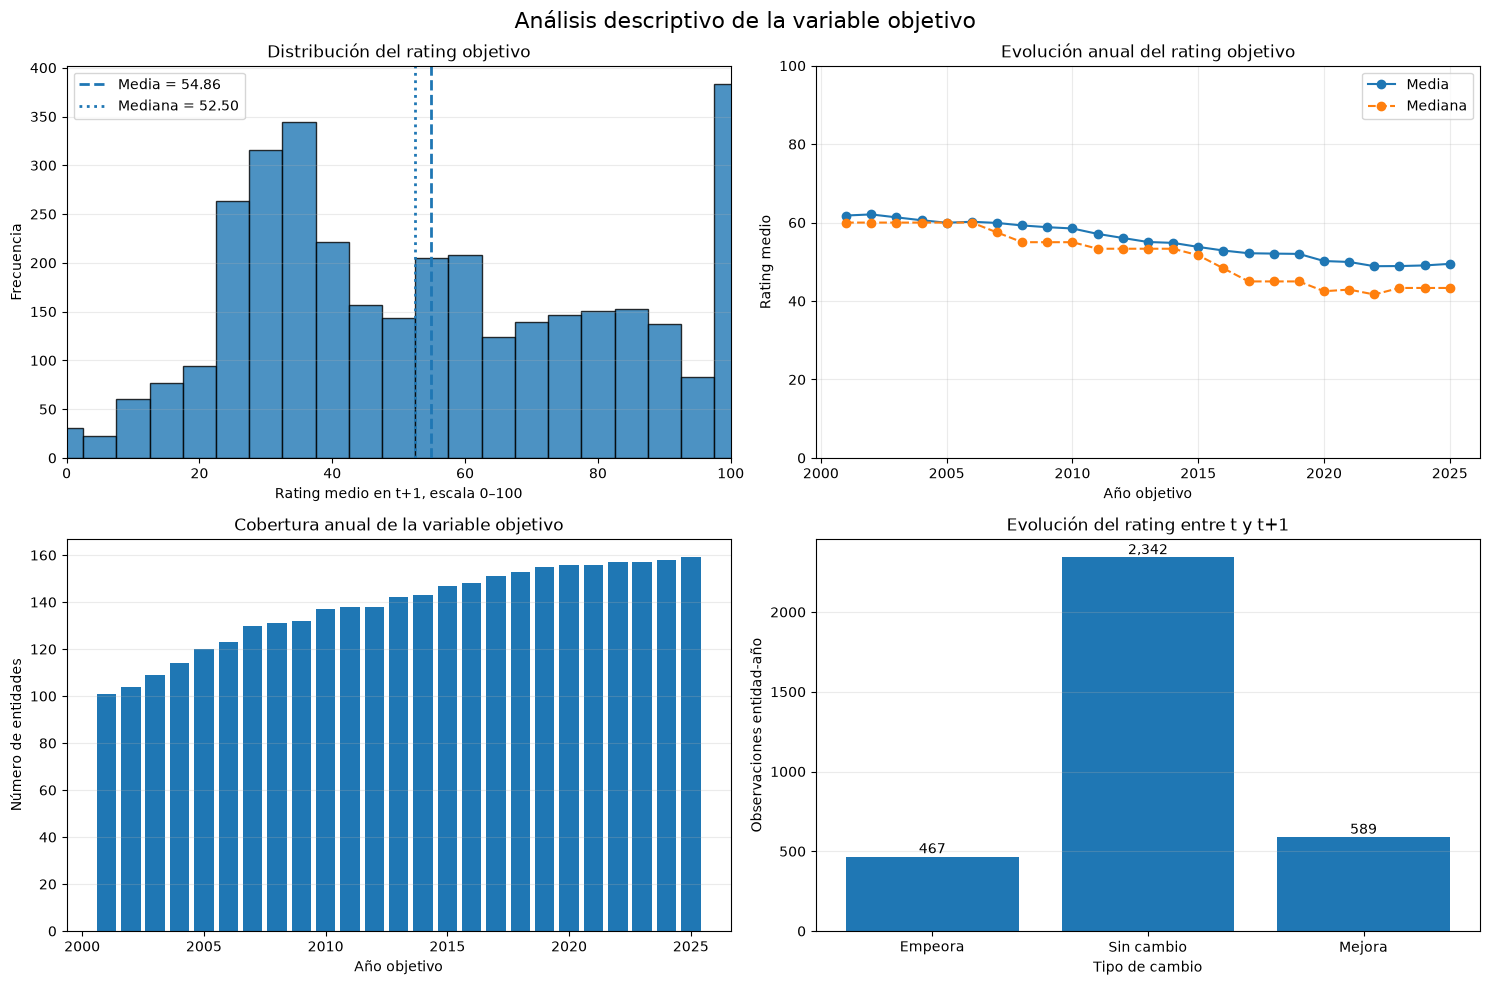

Variable objetivo: target_rating_score_t1
Variables explicativas: 2000–2024
Ratings objetivo: 2001–2025


,iso3,entity_name,year,rating_score_mean,target_year,target_rating_score_t1,target_number_of_ratings_t1
9,ABW,Aruba,2009,<NA>,2010,70.0,1
10,ABW,Aruba,2010,70.0,2011,70.0,1
11,ABW,Aruba,2011,70.0,2012,70.0,1
12,ABW,Aruba,2012,70.0,2013,65.0,1
13,ABW,Aruba,2013,65.0,2014,65.0,1
14,ABW,Aruba,2014,65.0,2015,65.0,1
15,ABW,Aruba,2015,65.0,2016,65.0,1
16,ABW,Aruba,2016,65.0,2017,65.0,1
17,ABW,Aruba,2017,65.0,2018,65.0,1
18,ABW,Aruba,2018,65.0,2019,65.0,1


In [77]:
# ============================================================
# ANÁLISIS DESCRIPTIVO DE LA VARIABLE OBJETIVO
#
# rating_score_mean:
#   rating medio observado en el año t
#
# target_rating_score_t1:
#   rating medio observado en el año t+1
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ------------------------------------------------------------
# 1. Crear la variable objetivo t+1
# ------------------------------------------------------------

rating_target_panel = (
    rating_entity_year
    .copy()
    .sort_values(
        ["iso3", "year"]
    )
    .reset_index(drop=True)
)


entity_groups = rating_target_panel.groupby(
    "iso3",
    sort=False
)


# Año siguiente disponible para cada entidad
rating_target_panel["next_observed_year"] = (
    entity_groups["year"]
    .shift(-1)
)


# Variable objetivo: rating medio del año siguiente
rating_target_panel["target_rating_score_t1"] = (
    entity_groups["rating_score_mean"]
    .shift(-1)
)


# Información complementaria del rating objetivo
rating_target_panel["target_number_of_ratings_t1"] = (
    entity_groups["number_of_ratings"]
    .shift(-1)
)

rating_target_panel["target_rating_range_t1"] = (
    entity_groups["rating_score_range"]
    .shift(-1)
)

rating_target_panel["target_rating_std_t1"] = (
    entity_groups["rating_score_std"]
    .shift(-1)
)


rating_target_panel["target_year"] = (
    rating_target_panel["year"] + 1
)


# Solo se considera t+1 cuando el siguiente registro
# corresponde exactamente al año siguiente
valid_next_year = (
    rating_target_panel["next_observed_year"]
    ==
    rating_target_panel["target_year"]
)


target_columns = [
    "target_rating_score_t1",
    "target_number_of_ratings_t1",
    "target_rating_range_t1",
    "target_rating_std_t1"
]


rating_target_panel.loc[
    ~valid_next_year,
    target_columns
] = np.nan


# Las variables explicativas llegan hasta 2024
model_end_year = (
    END_YEAR
    if "END_YEAR" in globals()
    else 2024
)


model_panel = (
    rating_target_panel[
        rating_target_panel["year"]
        <= model_end_year
    ]
    .copy()
)


# Muestra disponible para entrenar
target_sample = (
    model_panel
    .dropna(
        subset=["target_rating_score_t1"]
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Variables descriptivas adicionales
# ------------------------------------------------------------

# Grado de inversión:
# BBB-/Baa3 o superior equivale a una puntuación >= 55
target_sample["target_investment_grade"] = (
    target_sample["target_rating_score_t1"]
    >= 55
)


# Cambio del rating entre t y t+1
target_sample["rating_change_t1"] = (
    target_sample["target_rating_score_t1"]
    -
    target_sample["rating_score_mean"]
)


# Clasificación del cambio
# Asegurar que la variación sea numérica
target_sample["rating_change_t1"] = pd.to_numeric(
    target_sample["rating_change_t1"],
    errors="coerce"
)

# Clasificación robusta del cambio
target_sample["rating_change_type"] = pd.Series(
    pd.NA,
    index=target_sample.index,
    dtype="string"
)

valid_change = target_sample["rating_change_t1"].notna()

target_sample.loc[
    valid_change & target_sample["rating_change_t1"].lt(0),
    "rating_change_type"
] = "Empeora"

target_sample.loc[
    valid_change & target_sample["rating_change_t1"].gt(0),
    "rating_change_type"
] = "Mejora"

target_sample.loc[
    valid_change & target_sample["rating_change_t1"].abs().lt(1e-9),
    "rating_change_type"
] = "Sin cambio"

# Solo tiene sentido analizar el cambio cuando existe
# rating tanto en t como en t+1
change_sample = (
    target_sample
    .dropna(
        subset=[
            "rating_score_mean",
            "target_rating_score_t1"
        ]
    )
    .copy()
)


# ------------------------------------------------------------
# 3. Resumen descriptivo
# ------------------------------------------------------------

target_values = (
    target_sample["target_rating_score_t1"]
    .astype(float)
)


missing_target_pct = (
    model_panel["target_rating_score_t1"]
    .isna()
    .mean()
    * 100
)


unchanged_pct = (
    change_sample["rating_change_t1"]
    .abs()
    .lt(1e-9)
    .mean()
    * 100
)


summary = pd.DataFrame({
    "Indicador": [
        "Observaciones entidad-año",
        "Entidades",
        "Periodo objetivo",
        "Media",
        "Mediana",
        "Desviación estándar",
        "Mínimo",
        "Percentil 25",
        "Percentil 75",
        "Máximo",
        "Grado de inversión",
        "Número medio de agencias",
        "Desacuerdo medio entre agencias",
        "Objetivos ausentes",
        "Ratings sin cambio anual"
    ],

    "Resultado": [
        f"{len(target_sample):,}",
        f"{target_sample['iso3'].nunique():,}",
        (
            f"{int(target_sample['target_year'].min())}"
            f"–"
            f"{int(target_sample['target_year'].max())}"
        ),
        f"{target_values.mean():.2f}",
        f"{target_values.median():.2f}",
        f"{target_values.std():.2f}",
        f"{target_values.min():.2f}",
        f"{target_values.quantile(0.25):.2f}",
        f"{target_values.quantile(0.75):.2f}",
        f"{target_values.max():.2f}",
        (
            f"{target_sample['target_investment_grade'].mean() * 100:.2f}%"
        ),
        (
            f"{target_sample['target_number_of_ratings_t1'].mean():.2f}"
        ),
        (
            f"{target_sample['target_rating_range_t1'].mean():.2f}"
        ),
        f"{missing_target_pct:.2f}%",
        f"{unchanged_pct:.2f}%"
    ]
})


display(
    summary.style
    .hide(axis="index")
    .set_caption(
        "Resumen de la variable objetivo: rating medio en t+1"
    )
)


# ------------------------------------------------------------
# 4. Estadísticas anuales
# ------------------------------------------------------------

annual_target_summary = (
    target_sample
    .groupby(
        "target_year",
        as_index=False
    )
    .agg(
        rating_mean=(
            "target_rating_score_t1",
            "mean"
        ),
        rating_median=(
            "target_rating_score_t1",
            "median"
        ),
        entities=(
            "iso3",
            "nunique"
        ),
        investment_grade_pct=(
            "target_investment_grade",
            "mean"
        )
    )
)


annual_target_summary["investment_grade_pct"] *= 100


change_counts = (
    change_sample["rating_change_type"]
    .value_counts()
    .reindex(
        [
            "Empeora",
            "Sin cambio",
            "Mejora"
        ],
        fill_value=0
    )
)


# ------------------------------------------------------------
# 5. Visualización conjunta
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(15, 10)
)


# Gráfico 1: distribución de la variable objetivo
axes[0, 0].hist(
    target_values,
    bins=np.arange(-2.5, 105, 5),
    edgecolor="black",
    alpha=0.8
)

axes[0, 0].axvline(
    target_values.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Media = {target_values.mean():.2f}"
)

axes[0, 0].axvline(
    target_values.median(),
    linestyle=":",
    linewidth=2,
    label=f"Mediana = {target_values.median():.2f}"
)

axes[0, 0].set_title(
    "Distribución del rating objetivo"
)

axes[0, 0].set_xlabel(
    "Rating medio en t+1, escala 0–100"
)

axes[0, 0].set_ylabel(
    "Frecuencia"
)

axes[0, 0].set_xlim(
    0,
    100
)

axes[0, 0].legend()

axes[0, 0].grid(
    axis="y",
    alpha=0.25
)


# Gráfico 2: evolución de media y mediana
axes[0, 1].plot(
    annual_target_summary["target_year"],
    annual_target_summary["rating_mean"],
    marker="o",
    label="Media"
)

axes[0, 1].plot(
    annual_target_summary["target_year"],
    annual_target_summary["rating_median"],
    marker="o",
    linestyle="--",
    label="Mediana"
)

axes[0, 1].set_title(
    "Evolución anual del rating objetivo"
)

axes[0, 1].set_xlabel(
    "Año objetivo"
)

axes[0, 1].set_ylabel(
    "Rating medio"
)

axes[0, 1].set_ylim(
    0,
    100
)

axes[0, 1].legend()

axes[0, 1].grid(
    alpha=0.25
)


# Gráfico 3: cobertura anual
axes[1, 0].bar(
    annual_target_summary["target_year"],
    annual_target_summary["entities"]
)

axes[1, 0].set_title(
    "Cobertura anual de la variable objetivo"
)

axes[1, 0].set_xlabel(
    "Año objetivo"
)

axes[1, 0].set_ylabel(
    "Número de entidades"
)

axes[1, 0].grid(
    axis="y",
    alpha=0.25
)


# Gráfico 4: cambios anuales
axes[1, 1].bar(
    change_counts.index,
    change_counts.values
)

axes[1, 1].set_title(
    "Evolución del rating entre t y t+1"
)

axes[1, 1].set_xlabel(
    "Tipo de cambio"
)

axes[1, 1].set_ylabel(
    "Observaciones entidad-año"
)

axes[1, 1].grid(
    axis="y",
    alpha=0.25
)


# Etiquetas sobre las barras
for position, value in enumerate(
    change_counts.values
):

    axes[1, 1].text(
        position,
        value,
        f"{value:,}",
        ha="center",
        va="bottom"
    )


fig.suptitle(
    "Análisis descriptivo de la variable objetivo",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 6. Comprobación de la estructura final
# ------------------------------------------------------------

print(
    "Variable objetivo:",
    "target_rating_score_t1"
)

print(
    "Variables explicativas:",
    f"{int(target_sample['year'].min())}"
    f"–{int(target_sample['year'].max())}"
)

print(
    "Ratings objetivo:",
    f"{int(target_sample['target_year'].min())}"
    f"–{int(target_sample['target_year'].max())}"
)


display(
    rating_target_panel[
        [
            "iso3",
            "entity_name",
            "year",
            "rating_score_mean",
            "target_year",
            "target_rating_score_t1",
            "target_number_of_ratings_t1"
        ]
    ]
    .dropna(
        subset=["target_rating_score_t1"]
    )
    .head(10)
)